# Time-Domain Features in EEG

This notebook is a hands-on walkthrough of **15 time-domain features** commonly used in EEG analysis.
We start with synthetic signals to build intuition, then apply everything to real **BrainBit** and **CalmSync** epochs.

**Outline**
1. Feature walkthrough on synthetic EEG
2. Load & preprocess real data (BrainBit + CalmSync)
3. Epoch extraction with trial metadata
4. Extract all 15 features per epoch
5. Visualise & compare — within device and between devices
6. How epoch duration and artifact rejection affect features

---
## 0 · Imports & Style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, warnings, sys
from pathlib import Path
from scipy import stats, signal
from scipy.signal import welch, hilbert, find_peaks

import pyxdf
import mne

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.dpi':       110,
})

C_FP1 = '#2166ac'
C_FP2 = '#d6604d'
C_SIGNAL = '#2c3e50'

print('Ready')

Ready


---
## 1 · Feature Walkthrough on Synthetic EEG

We build a realistic-looking synthetic EEG signal with known properties, then compute each feature and see what it tells us.

### The 15 features

| # | Feature | What it captures |
|---|---------|------------------|
| 1 | **Skewness** | Asymmetry of amplitude distribution — positive means more large positive peaks |
| 2 | **Kurtosis** | "Peakedness" — high kurtosis = sharp transients / spikes |
| 3 | **Slope Sign Changes (SSC)** | How often the signal changes direction — proxy for high-frequency content |
| 4 | **Zero Crossing Rate (ZCR)** | How often the signal crosses zero — related to dominant frequency |
| 5 | **Hjorth Mobility** | Ratio of std of first derivative to std of signal — related to mean frequency |
| 6 | **Hjorth Complexity** | How much the signal shape deviates from a pure sine wave |
| 7–11 | **Autocorrelation at band lags** | How self-similar the signal is at lags corresponding to delta (2 Hz), theta (6 Hz), alpha (10 Hz), beta (20 Hz), gamma (35 Hz) |
| 12–13 | **ACF Peak 1 freq & r** | Frequency and strength of the strongest autocorrelation peak — reveals dominant rhythm |
| 14–15 | **ACF Peak 2 freq & r** | Second strongest ACF peak — reveals secondary rhythm |

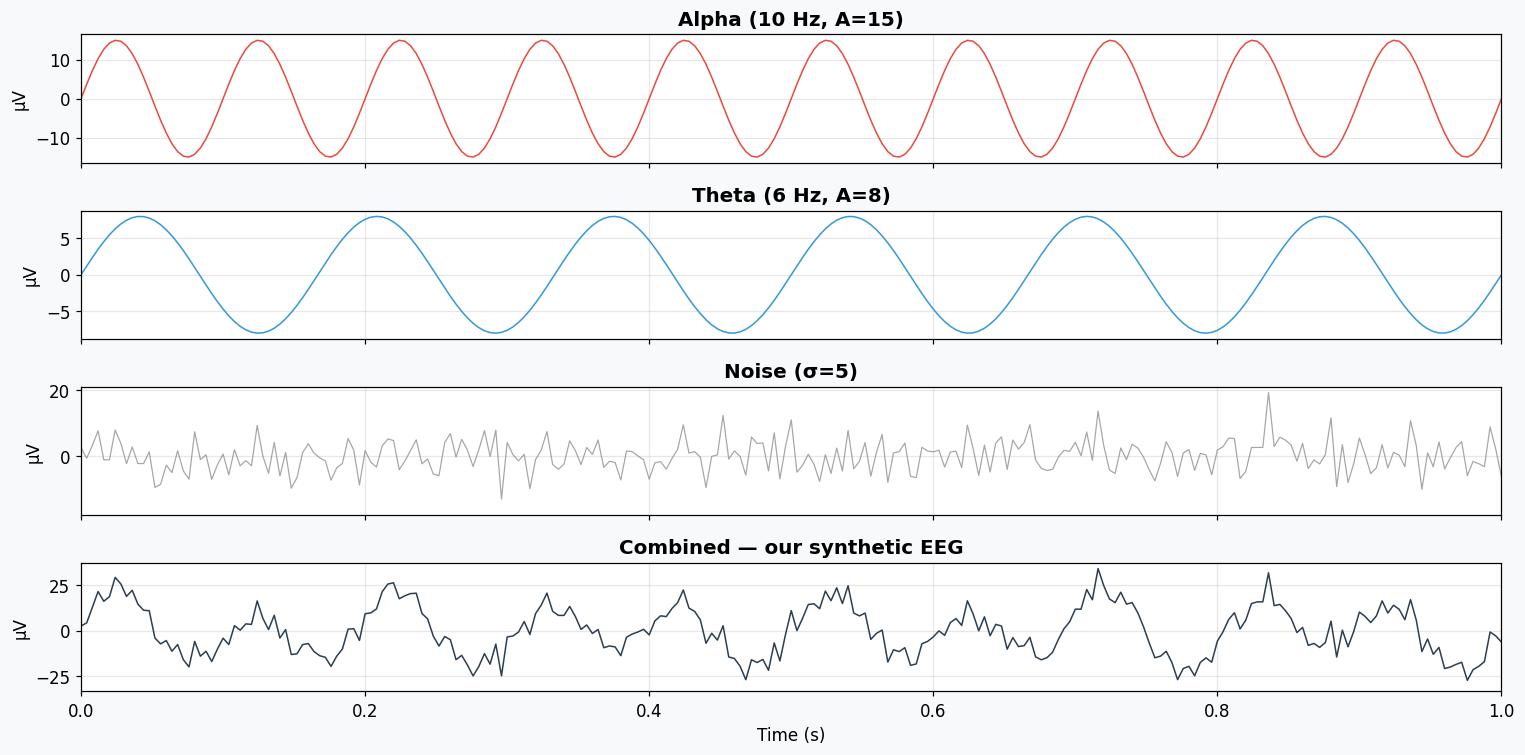

In [2]:
# ── Synthetic EEG: alpha + theta + noise ─────────────────────────────────────
np.random.seed(42)
fs_syn = 250
dur_syn = 4  # seconds
t_syn = np.arange(0, dur_syn, 1/fs_syn)

alpha = 15.0 * np.sin(2 * np.pi * 10 * t_syn)    # 10 Hz, ~EEG-scale µV
theta =  8.0 * np.sin(2 * np.pi * 6  * t_syn)    #  6 Hz
noise =  5.0 * np.random.randn(len(t_syn))        # Gaussian noise

synth = alpha + theta + noise

fig, axes = plt.subplots(4, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t_syn, alpha, color='#e74c3c', lw=1); axes[0].set(ylabel='µV', title='Alpha (10 Hz, A=15)')
axes[1].plot(t_syn, theta, color='#3498db', lw=1); axes[1].set(ylabel='µV', title='Theta (6 Hz, A=8)')
axes[2].plot(t_syn, noise, color='grey', lw=0.8, alpha=0.7); axes[2].set(ylabel='µV', title='Noise (σ=5)')
axes[3].plot(t_syn, synth, color=C_SIGNAL, lw=1); axes[3].set(ylabel='µV', title='Combined — our synthetic EEG', xlabel='Time (s)')
for ax in axes: ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

### 1a · Helper functions

We reuse the same feature extraction from `03_time_domain_features.py`.

In [3]:
# ── FFT-based autocorrelation ────────────────────────────────────────────────
def acf_fft(x, max_lag):
    """Compute autocorrelation using FFT."""
    n = len(x)
    x_c = x - np.mean(x)
    fft_size = 1
    while fft_size < 2 * n:
        fft_size *= 2
    fft_x = np.fft.rfft(x_c, n=fft_size)
    acf_full = np.fft.irfft(fft_x * np.conj(fft_x), n=fft_size)[:max_lag]
    if acf_full[0] > 0:
        acf_full = acf_full / acf_full[0]
    return acf_full


def extract_features(x, fs):
    """Extract 15 time-domain features from a 1D EEG signal."""
    dx = np.diff(x)
    ddx = np.diff(dx)
    var0, var1 = np.var(x), np.var(dx)
    mob = np.sqrt(var1 / var0) if var0 > 0 else np.nan

    feats = {
        'td_skewness': float(stats.skew(x, bias=False)),
        'td_kurtosis': float(stats.kurtosis(x, fisher=True, bias=False)),
        'td_ssc':      float(np.mean(((x[1:-1] - x[:-2]) * (x[1:-1] - x[2:])) > 0)),
        'td_zcr':      float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1]))),
        'hjorth_mob':  float(mob),
        'hjorth_cplx': float(
            (np.sqrt(np.var(ddx) / var1) / mob) if var1 > 0 and mob > 0 else np.nan
        ),
    }

    # Autocorrelation at band-specific lags
    freq_lags = {
        'ac_delta(2Hz)':  int(fs / 2),
        'ac_theta(6Hz)':  int(fs / 6),
        'ac_alpha(10Hz)': int(fs / 10),
        'ac_beta(20Hz)':  int(fs / 20),
        'ac_gamma(35Hz)': int(fs / 35),
    }
    for name, lag in freq_lags.items():
        if lag < len(x):
            feats[name] = float(np.corrcoef(x[:-lag], x[lag:])[0, 1])
        else:
            feats[name] = np.nan

    # ACF peaks
    max_lag = min(int(1.0 * fs), len(x) // 2)
    acf = acf_fft(x, max_lag)
    peaks, _ = find_peaks(acf[1:], distance=int(0.02 * fs), height=0.0)
    peaks += 1

    feats['acf_peak1_freq_hz'] = float(fs / peaks[0]) if len(peaks) > 0 else np.nan
    feats['acf_peak1_r']       = float(acf[peaks[0]])  if len(peaks) > 0 else np.nan
    feats['acf_peak2_freq_hz'] = float(fs / peaks[1]) if len(peaks) > 1 else np.nan
    feats['acf_peak2_r']       = float(acf[peaks[1]])  if len(peaks) > 1 else np.nan

    return feats

print('Feature functions defined')

Feature functions defined


### 1b · Skewness & Kurtosis — amplitude distribution shape

- **Skewness ≈ 0** → symmetric distribution (typical for clean EEG)
- **Kurtosis < 0** (sub-Gaussian) → signal is flatter than Gaussian (sinusoids do this)
- **Kurtosis > 0** (super-Gaussian) → sharp peaks / transients (artifacts, spikes)

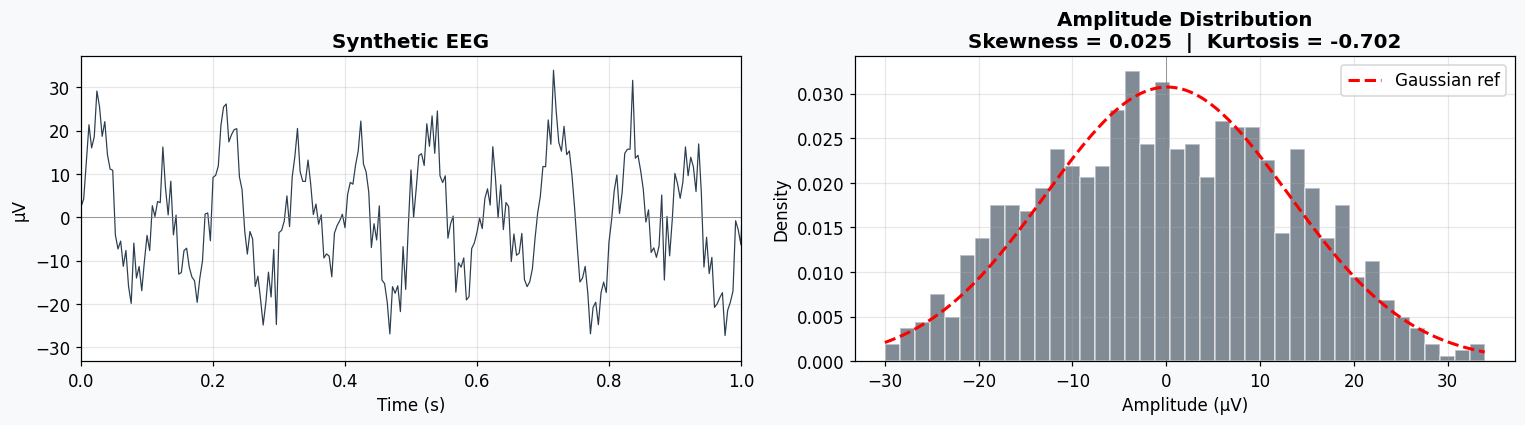

  Skewness = 0.0248  (≈0 → symmetric, good)
  Kurtosis = -0.7020  (<0 → flatter than Gaussian, sine-like)


In [4]:
# ── Skewness & Kurtosis visualised ───────────────────────────────────────────
skew_val = stats.skew(synth, bias=False)
kurt_val = stats.kurtosis(synth, fisher=True, bias=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: signal
axes[0].plot(t_syn, synth, color=C_SIGNAL, lw=0.8)
axes[0].axhline(0, color='grey', lw=0.5)
axes[0].set(xlabel='Time (s)', ylabel='µV', title='Synthetic EEG', xlim=(0, 1))

# Right: histogram
axes[1].hist(synth, bins=40, density=True, color=C_SIGNAL, alpha=0.6, edgecolor='white')
axes[1].axvline(0, color='grey', lw=0.5)
axes[1].set(xlabel='Amplitude (µV)', ylabel='Density',
            title=f'Amplitude Distribution\nSkewness = {skew_val:.3f}  |  Kurtosis = {kurt_val:.3f}')

# Overlay Gaussian for reference
x_range = np.linspace(synth.min(), synth.max(), 200)
axes[1].plot(x_range, stats.norm.pdf(x_range, synth.mean(), synth.std()),
             'r--', lw=2, label='Gaussian ref')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'  Skewness = {skew_val:.4f}  (≈0 → symmetric, good)')
print(f'  Kurtosis = {kurt_val:.4f}  (<0 → flatter than Gaussian, sine-like)')

### 1c · Zero Crossing Rate (ZCR) & Slope Sign Changes (SSC)

- **ZCR** — how often the signal crosses zero. Higher ZCR → higher dominant frequency.
  - A pure 10 Hz sine crosses zero 20 times/sec → ZCR ≈ 20/fs
- **SSC** — how often the slope changes sign (local peaks & troughs). Higher SSC → more high-frequency content.

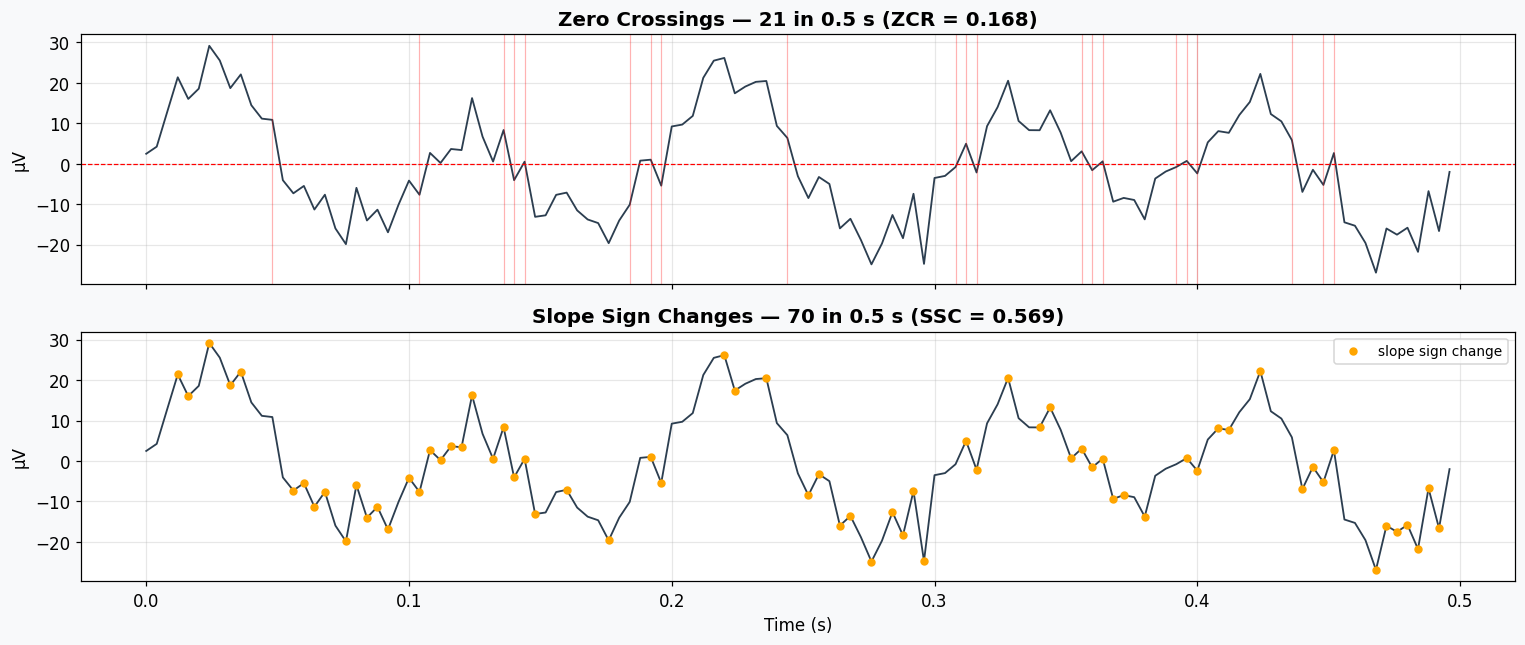

In [5]:
# ── ZCR & SSC visualised ─────────────────────────────────────────────────────
# Show on a short segment
seg = synth[:125]  # 0.5 seconds
t_seg = t_syn[:125]

# Zero crossings
zc_idx = np.where(np.diff(np.signbit(seg)))[0]

# Slope sign changes
dx_seg = np.diff(seg)
ssc_idx = np.where(((seg[1:-1] - seg[:-2]) * (seg[1:-1] - seg[2:])) > 0)[0] + 1

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# ZCR
axes[0].plot(t_seg, seg, color=C_SIGNAL, lw=1.2)
axes[0].axhline(0, color='red', lw=0.8, ls='--')
for zc in zc_idx:
    axes[0].axvline(t_seg[zc], color='red', alpha=0.3, lw=0.8)
axes[0].set(ylabel='µV', title=f'Zero Crossings — {len(zc_idx)} in 0.5 s (ZCR = {len(zc_idx)/len(seg):.3f})')

# SSC
axes[1].plot(t_seg, seg, color=C_SIGNAL, lw=1.2)
axes[1].scatter(t_seg[ssc_idx], seg[ssc_idx], color='orange', s=20, zorder=5, label='slope sign change')
axes[1].set(xlabel='Time (s)', ylabel='µV',
            title=f'Slope Sign Changes — {len(ssc_idx)} in 0.5 s (SSC = {len(ssc_idx)/max(len(seg)-2,1):.3f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 1d · Hjorth Parameters — Mobility & Complexity

Defined by Bo Hjorth (1970) as simple statistical descriptors:

- **Mobility** = $\sqrt{\text{var}(x') / \text{var}(x)}$ — proportional to the mean frequency
- **Complexity** = $\text{Mobility}(x') / \text{Mobility}(x)$ — how much the shape deviates from a pure sine
  - For a pure sine: complexity ≈ 1.0
  - For noisy/complex signals: complexity > 1.0

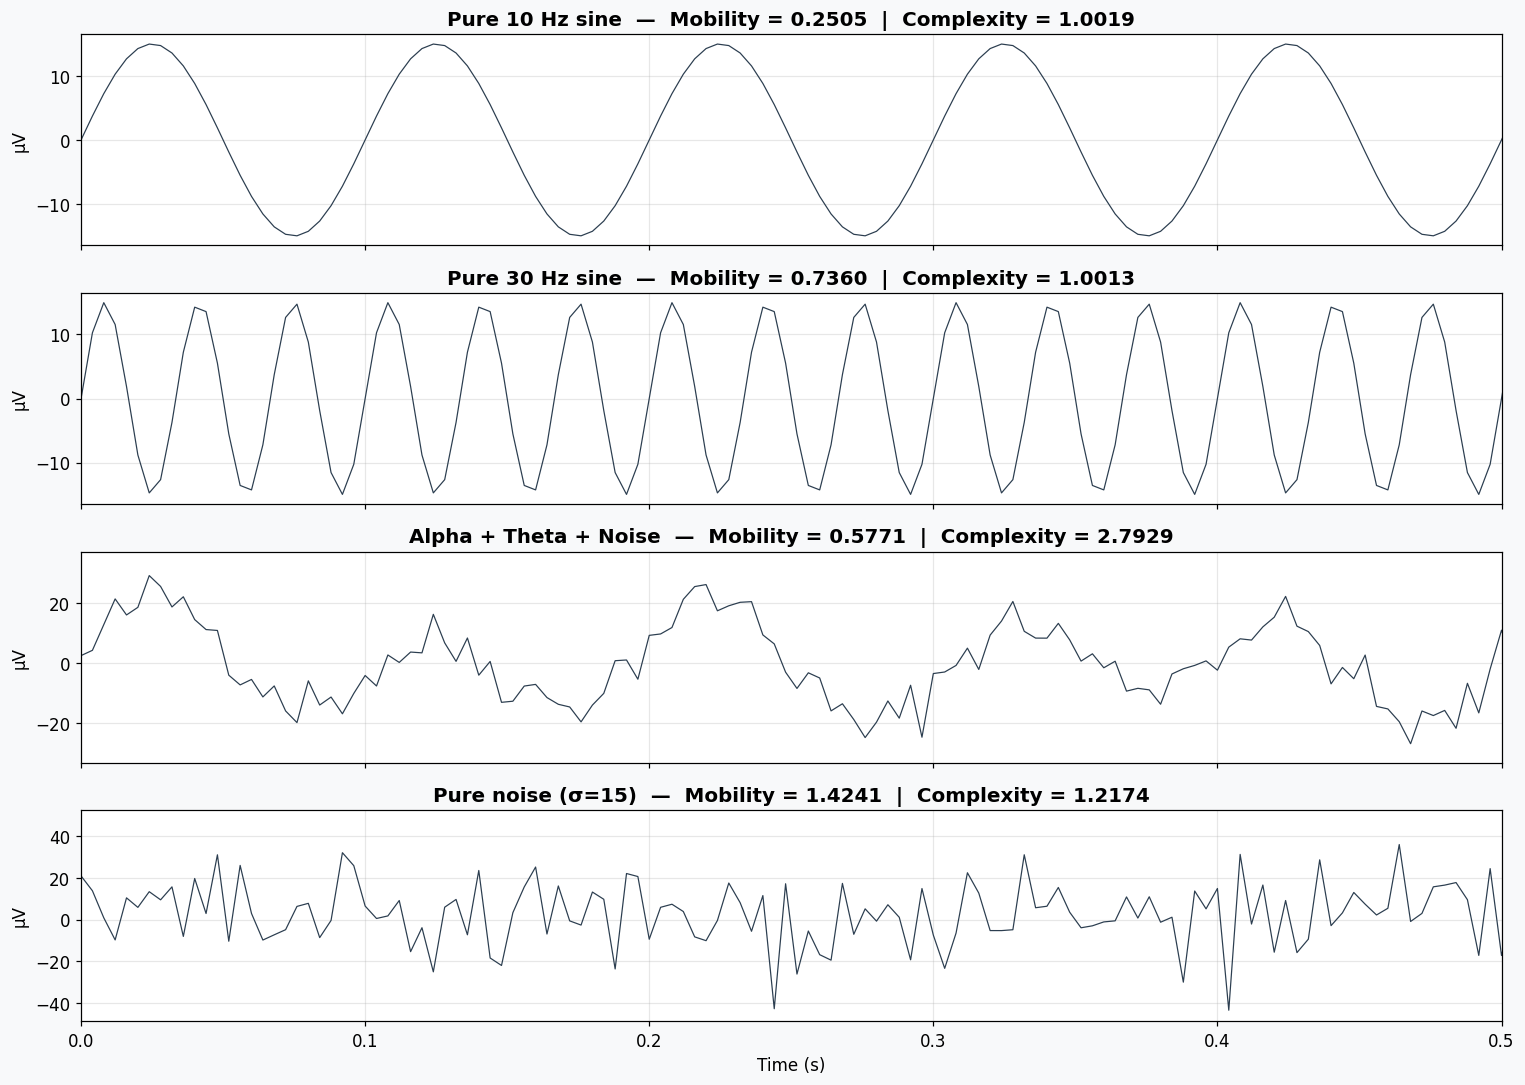


Hjorth Parameter Summary:
               Signal  Mobility  Complexity
      Pure 10 Hz sine  0.250545    1.001913
      Pure 30 Hz sine  0.735980    1.001264
Alpha + Theta + Noise  0.577090    2.792872
    Pure noise (σ=15)  1.424132    1.217400

  Higher mobility → higher mean frequency
  Complexity ≈ 1 → sine-like, > 1 → more complex waveform


In [6]:
# ── Hjorth parameters for different signals ──────────────────────────────────
signals = {
    'Pure 10 Hz sine':    15.0 * np.sin(2 * np.pi * 10 * t_syn),
    'Pure 30 Hz sine':    15.0 * np.sin(2 * np.pi * 30 * t_syn),
    'Alpha + Theta + Noise': synth,
    'Pure noise (σ=15)':  15.0 * np.random.randn(len(t_syn)),
}

fig, axes = plt.subplots(len(signals), 1, figsize=(14, 2.5 * len(signals)), sharex=True)

hjorth_data = []
for ax, (name, sig) in zip(axes, signals.items()):
    dx = np.diff(sig)
    ddx = np.diff(dx)
    var0, var1 = np.var(sig), np.var(dx)
    mob = np.sqrt(var1 / var0) if var0 > 0 else np.nan
    cplx = (np.sqrt(np.var(ddx) / var1) / mob) if var1 > 0 and mob > 0 else np.nan

    ax.plot(t_syn, sig, color=C_SIGNAL, lw=0.8)
    ax.set(ylabel='µV', title=f'{name}  —  Mobility = {mob:.4f}  |  Complexity = {cplx:.4f}')
    ax.set_xlim(0, 0.5)
    hjorth_data.append({'Signal': name, 'Mobility': mob, 'Complexity': cplx})

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

print('\nHjorth Parameter Summary:')
print(pd.DataFrame(hjorth_data).to_string(index=False))
print('\n  Higher mobility → higher mean frequency')
print('  Complexity ≈ 1 → sine-like, > 1 → more complex waveform')

### 1e · Autocorrelation at band-specific lags

If the signal has a strong 10 Hz rhythm, it should be highly correlated with itself delayed by 1/10 s = 25 samples (at 250 Hz).

We check autocorrelation at lags corresponding to:
- Delta (2 Hz): lag = 125 samples
- Theta (6 Hz): lag = 41 samples
- Alpha (10 Hz): lag = 25 samples
- Beta (20 Hz): lag = 12 samples
- Gamma (35 Hz): lag = 7 samples

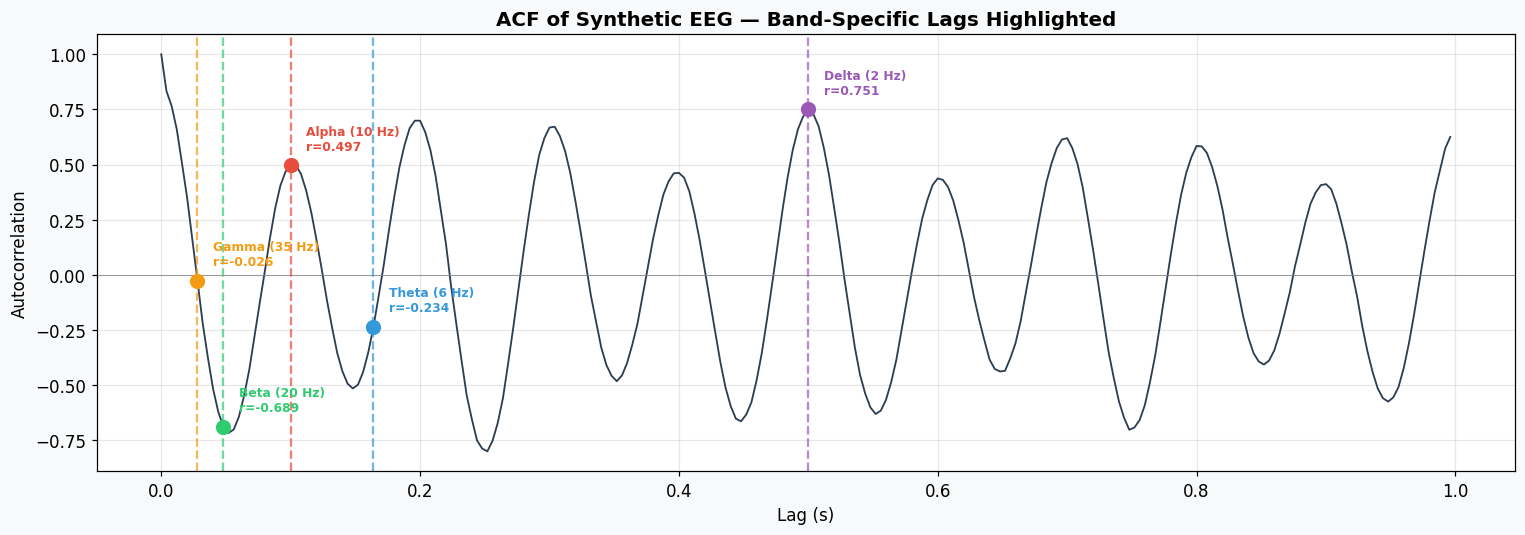

  Alpha lag has highest correlation → dominant 10 Hz rhythm detected


In [7]:
# ── Autocorrelation function + band lags ─────────────────────────────────────
max_lag = min(int(1.0 * fs_syn), len(synth) // 2)
acf = acf_fft(synth, max_lag)
lags_time = np.arange(max_lag) / fs_syn

band_lags = {
    'Delta (2 Hz)':  int(fs_syn / 2),
    'Theta (6 Hz)':  int(fs_syn / 6),
    'Alpha (10 Hz)': int(fs_syn / 10),
    'Beta (20 Hz)':  int(fs_syn / 20),
    'Gamma (35 Hz)': int(fs_syn / 35),
}
band_colors_ac = ['#9b59b6', '#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lags_time, acf, color=C_SIGNAL, lw=1.2)
ax.axhline(0, color='grey', lw=0.5)

for (bname, lag), col in zip(band_lags.items(), band_colors_ac):
    if lag < max_lag:
        r = acf[lag]
        ax.axvline(lag/fs_syn, color=col, ls='--', lw=1.5, alpha=0.7)
        ax.scatter([lag/fs_syn], [r], color=col, s=80, zorder=5)
        ax.annotate(f'{bname}\nr={r:.3f}', (lag/fs_syn, r),
                    textcoords='offset points', xytext=(10, 10), fontsize=8,
                    color=col, fontweight='bold')

ax.set(xlabel='Lag (s)', ylabel='Autocorrelation',
       title='ACF of Synthetic EEG — Band-Specific Lags Highlighted')
plt.tight_layout()
plt.show()
print('  Alpha lag has highest correlation → dominant 10 Hz rhythm detected')

### 1f · ACF Peak Detection — finding dominant rhythms

We find peaks in the ACF and convert their lag positions to frequencies. The top 2 peaks reveal the dominant and secondary rhythms.

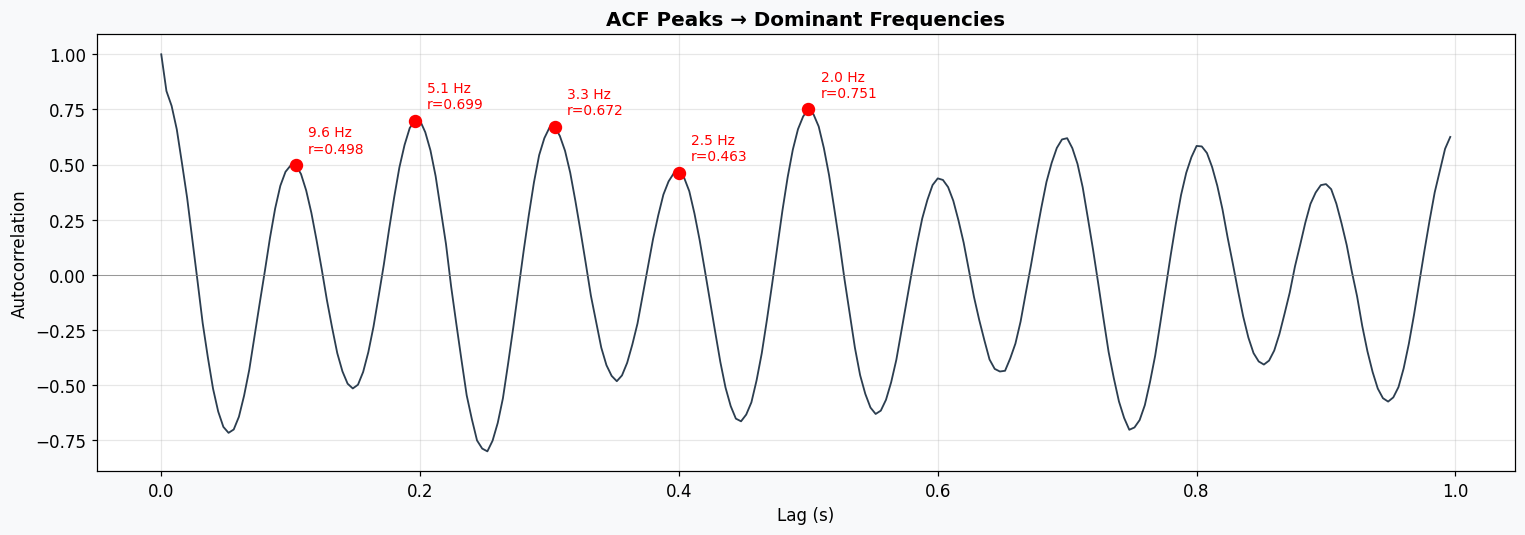

  Peak 1: 9.6 Hz (r = 0.498)
  Peak 2: 5.1 Hz (r = 0.699)


In [8]:
# ── ACF peaks ─────────────────────────────────────────────────────────────────
peaks_idx, props = find_peaks(acf[1:], distance=int(0.02 * fs_syn), height=0.0)
peaks_idx += 1

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lags_time, acf, color=C_SIGNAL, lw=1.2)
ax.axhline(0, color='grey', lw=0.5)

# Mark all peaks
for pi in peaks_idx[:5]:  # show top 5
    freq_hz = fs_syn / pi
    ax.scatter([pi/fs_syn], [acf[pi]], color='red', s=60, zorder=5)
    ax.annotate(f'{freq_hz:.1f} Hz\nr={acf[pi]:.3f}',
                (pi/fs_syn, acf[pi]), textcoords='offset points',
                xytext=(8, 8), fontsize=9, color='red')

ax.set(xlabel='Lag (s)', ylabel='Autocorrelation',
       title='ACF Peaks → Dominant Frequencies')
plt.tight_layout()
plt.show()

if len(peaks_idx) >= 2:
    print(f'  Peak 1: {fs_syn/peaks_idx[0]:.1f} Hz (r = {acf[peaks_idx[0]]:.3f})')
    print(f'  Peak 2: {fs_syn/peaks_idx[1]:.1f} Hz (r = {acf[peaks_idx[1]]:.3f})')

### 1g · All 15 features at a glance

In [9]:
# ── Extract all features from synthetic signal ────────────────────────────────
feats_synth = extract_features(synth, fs_syn)

df_feats = pd.DataFrame([
    {'Feature': k, 'Value': v}
    for k, v in feats_synth.items()
])

print('All 15 Time-Domain Features (synthetic EEG):')
print(df_feats.to_string(index=False))

All 15 Time-Domain Features (synthetic EEG):
          Feature     Value
      td_skewness  0.024848
      td_kurtosis -0.702025
           td_ssc  0.595190
           td_zcr  0.153153
       hjorth_mob  0.577090
      hjorth_cplx  2.792872
    ac_delta(2Hz)  0.860756
    ac_theta(6Hz) -0.243606
   ac_alpha(10Hz)  0.513166
    ac_beta(20Hz) -0.705180
   ac_gamma(35Hz) -0.026694
acf_peak1_freq_hz  9.615385
      acf_peak1_r  0.498204
acf_peak2_freq_hz  5.102041
      acf_peak2_r  0.699397


### 1h · How epoch duration changes features

Does it matter if our epoch is 0.5 s or 2 s?  Let's find out by extracting features from different durations of the same signal.

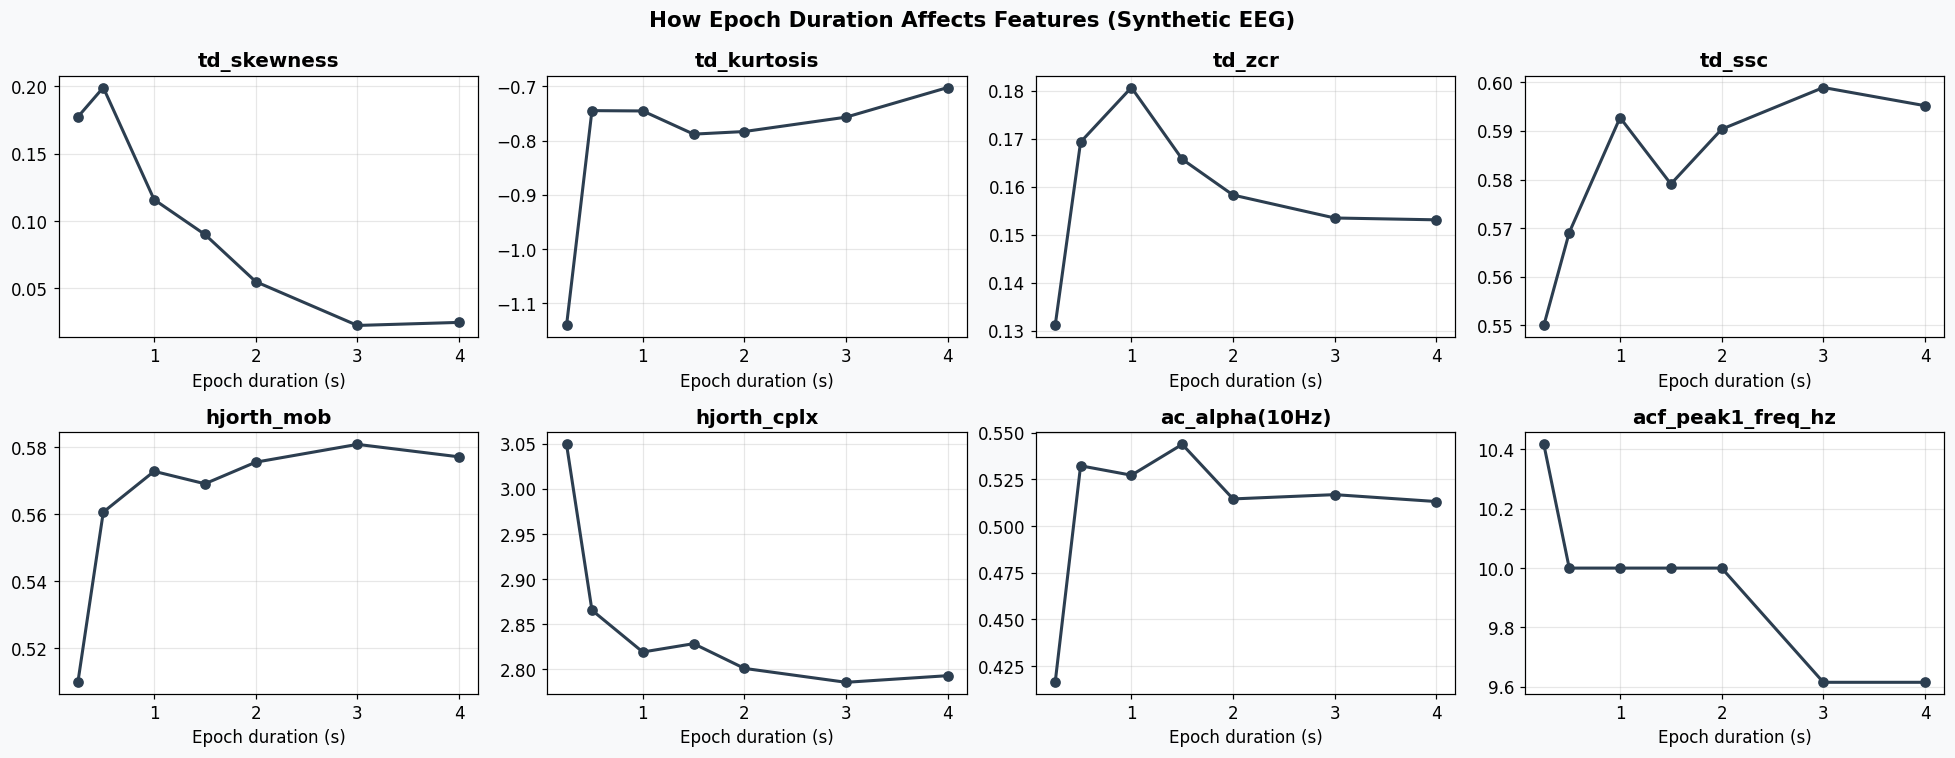

  Hjorth & ZCR are stable across durations.
  ACF-based features need at least ~0.5 s to be reliable.


In [10]:
# ── Epoch duration effect ────────────────────────────────────────────────────
# Build a longer synthetic signal
np.random.seed(42)
dur_long = 4
t_long = np.arange(0, dur_long, 1/fs_syn)
synth_long = (15.0 * np.sin(2 * np.pi * 10 * t_long)
              + 8.0 * np.sin(2 * np.pi * 6 * t_long)
              + 5.0 * np.random.randn(len(t_long)))

durations = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
dur_rows = []
for d in durations:
    n_samp = int(d * fs_syn)
    if n_samp > len(synth_long):
        continue
    feats_d = extract_features(synth_long[:n_samp], fs_syn)
    feats_d['duration_s'] = d
    dur_rows.append(feats_d)

df_dur = pd.DataFrame(dur_rows)

# Plot a selection of features vs duration
feat_sel = ['td_skewness', 'td_kurtosis', 'td_zcr', 'td_ssc',
            'hjorth_mob', 'hjorth_cplx', 'ac_alpha(10Hz)', 'acf_peak1_freq_hz']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, feat in zip(axes.flat, feat_sel):
    if feat in df_dur.columns:
        ax.plot(df_dur['duration_s'], df_dur[feat], 'o-', color=C_SIGNAL, lw=2)
        ax.set(xlabel='Epoch duration (s)', title=feat)
        ax.grid(True, alpha=0.3)

plt.suptitle('How Epoch Duration Affects Features (Synthetic EEG)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('  Hjorth & ZCR are stable across durations.')
print('  ACF-based features need at least ~0.5 s to be reliable.')

---
## 2 · Load & Preprocess Real Data

We load BrainBit (XDF, ~250 Hz) and CalmSync (JSON, ~240 Hz), apply:
- Notch filter at 50 + 100 Hz
- Bandpass filter (parameterised, default 0.5–45 Hz)
- Optional artifact rejection (off by default)

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PARAMETERS — change these as you like
# ══════════════════════════════════════════════════════════════════════════════
HP_FREQ   = 0.5     # high-pass (Hz)
LP_FREQ   = 45.0    # low-pass  (Hz)
NOTCH_HZ  = [50.0, 100.0]

TMIN      = -0.5    # epoch start relative to image_on (s)
TMAX      =  1.0    # epoch end   relative to image_on (s)
BASELINE  = (-0.2, 0.0)

REJECT_ARTIFACT = False   # set True to enable ±150 µV rejection
REJECT_UV       = 150.0   # threshold (µV)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE = Path(r'C:\Users\bwsin\Desktop\Osis_data')

BB_XDF = BASE / 'Data/Brainbit/Archi_27febgoodbadimages.xdf'
BB_CSV = BASE / 'Data/Brainbit/Archibrainbit_2702goodbadimages.csv'

CS_JSON = BASE / 'Data/Calmsync/eeg_2026-02-27T16-33-22_2026-02-27T16-36-16.json'
CS_CSV  = BASE / 'Data/Calmsync/Archi_calmsync_goodbadimages.csv'

BB_CHAN_NAMES = ['Fz', 'F3', 'Cz', 'F4', 'Pz', 'Fp1', 'Fp2', 'Oz']
BB_MARKER_MAP = {
    '10': 'baseline_start', '11': 'baseline_end',
    '20': 'fixation_on',    '21': 'fixation_off',
    '30': 'image_on',       '31': 'image_off',
    '40': 'response_on',    '41': 'response_off',
}

print('Parameters set')

Parameters set


In [12]:
# ── Load BrainBit ─────────────────────────────────────────────────────────────
streams, _ = pyxdf.load_xdf(str(BB_XDF))

eeg_s = marker_s = None
for s in streams:
    stype = s['info']['type'][0].lower()
    sname = s['info']['name'][0].lower()
    if stype == 'eeg' and len(s['time_stamps']) > 0:
        eeg_s = s
    if stype == 'markers' or 'marker' in sname:
        marker_s = s

raw_data = np.array(eeg_s['time_series']).T
eeg_ts   = np.array(eeg_s['time_stamps'])
eeg_t0   = eeg_ts[0]
bb_fs    = float(1.0 / np.median(np.diff(eeg_ts - eeg_t0)))

# Select Fp1, Fp2
fp1_i = BB_CHAN_NAMES.index('Fp1')
fp2_i = BB_CHAN_NAMES.index('Fp2')
bb_data = raw_data[[fp1_i, fp2_i], :]

# Scale to µV
max_abs = np.max(np.abs(bb_data))
if max_abs < 1.0:
    bb_data = bb_data * 1e6
    print(f'  Volts → µV (max raw = {max_abs:.4f})')
elif max_abs <= 1000:
    bb_data = bb_data * 1e3
    print(f'  mV → µV (max raw = {max_abs:.2f})')
else:
    print(f'  Already µV (max = {max_abs:.1f})')

# Build MNE Raw (data in Volts for MNE)
info_bb = mne.create_info(['Fp1', 'Fp2'], sfreq=bb_fs, ch_types='eeg')
raw_bb  = mne.io.RawArray(bb_data * 1e-6, info_bb, verbose=False)
raw_bb.set_montage('standard_1020', on_missing='ignore', verbose=False)

# Attach markers
dur_bb = (eeg_ts[-1] - eeg_t0)
mk_ts   = np.array(marker_s['time_stamps']) - eeg_t0
mk_vals = [str(v[0]).strip() for v in marker_s['time_series']]
onsets, durations, descs = [], [], []
for t_mk, v in zip(mk_ts, mk_vals):
    if 0 <= t_mk <= dur_bb:
        onsets.append(t_mk)
        durations.append(0.0)
        descs.append(BB_MARKER_MAP.get(v, v))
raw_bb.set_annotations(mne.Annotations(onsets, durations, descs))

print(f'  BrainBit: {bb_fs:.1f} Hz, {len(bb_data[0])} samples, '
      f'{dur_bb:.1f} s, {descs.count("image_on")} image_on events')

  Volts → µV (max raw = 0.2040)
  BrainBit: 249.6 Hz, 45440 samples, 182.0 s, 16 image_on events


In [13]:
# ── Load CalmSync ────────────────────────────────────────────────────────────
from datetime import datetime

with open(CS_JSON) as f:
    cs_d = json.load(f)

cs_fs   = float(cs_d['samplingRateHz'])
cs_raw  = np.array(cs_d['data'], dtype=float)

# ADC → µV
cs_data = ((cs_raw - 512) * 3.3 / 1024) / 1100 * 1e6

info_cs = mne.create_info(['Fp1', 'Fp2'], sfreq=cs_fs, ch_types='eeg')
raw_cs  = mne.io.RawArray(cs_data * 1e-6, info_cs, verbose=False)
raw_cs.set_montage('standard_1020', on_missing='ignore', verbose=False)

# Annotations from CSV
start_str      = CS_JSON.stem.split('_')[1]
rec_start_unix = datetime.strptime(start_str, '%Y-%m-%dT%H-%M-%S').timestamp()
dur_cs = cs_data.shape[1] / cs_fs

df_cs_ev = pd.read_csv(CS_CSV)
onsets_cs, durs_cs, descs_cs = [], [], []
for _, row in df_cs_ev.iterrows():
    t_eeg = float(row['unix_time']) - rec_start_unix
    if 0 <= t_eeg <= dur_cs:
        onsets_cs.append(t_eeg)
        durs_cs.append(0.0)
        descs_cs.append(str(row['event']).strip())
raw_cs.set_annotations(mne.Annotations(onsets_cs, durs_cs, descs_cs))

print(f'  CalmSync: {cs_fs:.1f} Hz, {cs_data.shape[1]} samples, '
      f'{dur_cs:.1f} s, {descs_cs.count("image_on")} image_on events')

  CalmSync: 239.7 Hz, 41646 samples, 173.7 s, 16 image_on events


In [14]:
# ── Preprocessing function ───────────────────────────────────────────────────
def preprocess_raw(raw, hp=HP_FREQ, lp=LP_FREQ, notch=NOTCH_HZ):
    """DC removal + bandpass + notch."""
    r = raw.copy()
    # DC removal
    data = r.get_data()
    for i in range(data.shape[0]):
        data[i] -= data[i].mean()
    r._data = data
    # Bandpass
    r.filter(l_freq=hp, h_freq=lp, method='fir', fir_window='hamming',
             fir_design='firwin', verbose=False)
    # Notch
    r.notch_filter(freqs=notch, method='fir', verbose=False)
    return r

raw_bb_filt = preprocess_raw(raw_bb)
raw_cs_filt = preprocess_raw(raw_cs)
print('Preprocessing done (both devices)')

Preprocessing done (both devices)


---
## 3 · Epoch Extraction with Trial Metadata

In [15]:
# ── Epoch extraction helper ──────────────────────────────────────────────────
def make_epochs(raw_filt, csv_path, tmin=TMIN, tmax=TMAX, baseline=BASELINE,
                reject_artifact=REJECT_ARTIFACT, reject_uv=REJECT_UV):
    """Extract epochs locked to image_on, attach trial metadata."""
    behavioral_df = pd.read_csv(csv_path)

    # Trial metadata
    img_df = (behavioral_df[behavioral_df['event'] == 'image_on']
              [['trial', 'image']].copy().reset_index(drop=True))
    img_df['trial'] = img_df['trial'].astype(int)

    resp_df = (behavioral_df[behavioral_df['event'] == 'response_off']
               [['trial', 'response', 'rating', 'reaction_time_ms']].copy()
               .dropna(subset=['response']))
    resp_df['trial']            = resp_df['trial'].astype(int)
    resp_df['response']         = resp_df['response'].astype(int)
    resp_df['rating']           = pd.to_numeric(resp_df['rating'], errors='coerce')
    resp_df['reaction_time_ms'] = pd.to_numeric(resp_df['reaction_time_ms'], errors='coerce')

    trial_meta = (img_df.merge(resp_df, on='trial', how='left')
                  .sort_values('trial').reset_index(drop=True))
    trial_meta['condition'] = trial_meta['rating'].apply(
        lambda r: 'liked' if (pd.notna(r) and r >= 6) else
                  'disliked' if (pd.notna(r) and r <= 4) else 'neutral'
    )

    # MNE events
    events, _ = mne.events_from_annotations(raw_filt, event_id={'image_on': 1}, verbose=False)
    n_use = min(len(events), len(trial_meta))

    epochs = mne.Epochs(
        raw_filt, events[:n_use],
        event_id={'image_on': 1},
        tmin=tmin, tmax=tmax,
        baseline=baseline,
        reject=None,
        metadata=trial_meta.iloc[:n_use].reset_index(drop=True),
        preload=True, verbose=False,
    )

    # Artifact rejection
    if reject_artifact:
        data_uv = epochs.get_data() * 1e6
        max_amps = np.max(np.abs(data_uv), axis=(1, 2))
        drop_idx = np.where(max_amps > reject_uv)[0].tolist()
        if drop_idx:
            epochs.drop(drop_idx, reason='amplitude', verbose=False)
        print(f'  Artifact rejection: dropped {len(drop_idx)}/{len(max_amps)} epochs')
    else:
        print(f'  Artifact rejection: OFF')

    conds = trial_meta.iloc[:n_use]['condition'].value_counts().to_dict()
    print(f'  Epochs: {len(epochs)}  |  conditions: {conds}')
    return epochs


epochs_bb = make_epochs(raw_bb_filt, BB_CSV)
print()
epochs_cs = make_epochs(raw_cs_filt, CS_CSV)

  Artifact rejection: OFF
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}

  Artifact rejection: OFF
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}


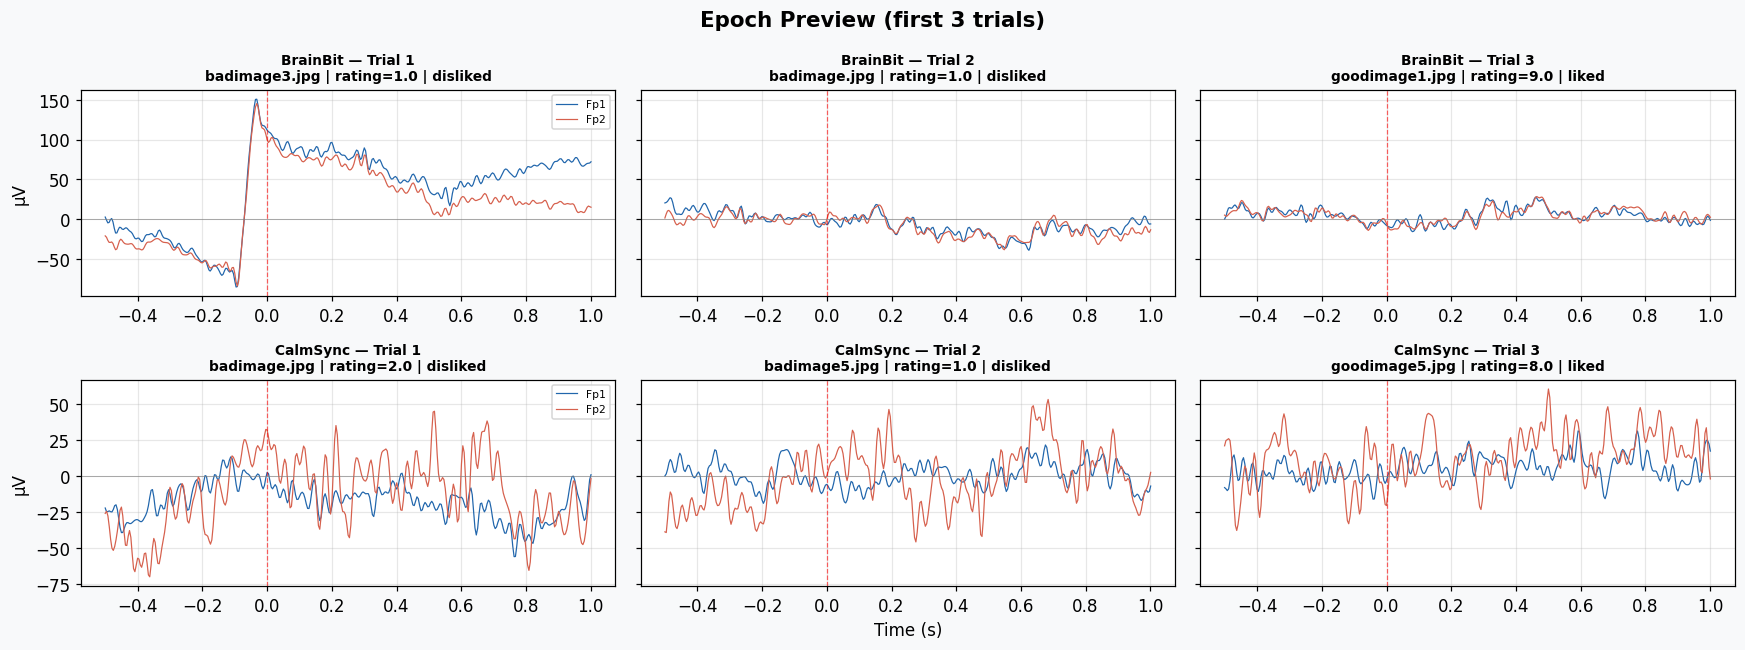

In [16]:
# ── Preview: first 3 epochs from each device ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 6), sharey='row')

for row, (epochs, name) in enumerate([(epochs_bb, 'BrainBit'), (epochs_cs, 'CalmSync')]):
    data_uv = epochs.get_data() * 1e6
    times = epochs.times
    for col in range(min(3, len(epochs))):
        ax = axes[row, col]
        meta = epochs.metadata.iloc[col]
        ax.plot(times, data_uv[col, 0], color=C_FP1, lw=0.8, label='Fp1')
        ax.plot(times, data_uv[col, 1], color=C_FP2, lw=0.8, label='Fp2')
        ax.axvline(0, color='red', ls='--', lw=0.8, alpha=0.6)
        ax.axhline(0, color='grey', lw=0.4)
        ax.set_title(f"{name} — Trial {int(meta['trial'])}\n{meta['image']} | "
                     f"rating={meta.get('rating','?')} | {meta['condition']}",
                     fontsize=9)
        if col == 0:
            ax.set_ylabel('µV')
            ax.legend(fontsize=7)

axes[1, 1].set_xlabel('Time (s)')
plt.suptitle('Epoch Preview (first 3 trials)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4 · Extract Time-Domain Features per Epoch

In [17]:
# ── Feature extraction for all epochs ─────────────────────────────────────────
def extract_all_features(epochs, device_name):
    """Extract 15 features per epoch per channel, return DataFrame."""
    data_uv = epochs.get_data() * 1e6
    fs = epochs.info['sfreq']
    ch_names = epochs.ch_names
    rows = []

    for i in range(len(epochs)):
        meta = epochs.metadata.iloc[i]
        for ch_idx, ch in enumerate(ch_names):
            row = {
                'device': device_name,
                'epoch_idx': i,
                'trial': int(meta['trial']),
                'image': meta['image'],
                'rating': meta.get('rating', np.nan),
                'reaction_time_ms': meta.get('reaction_time_ms', np.nan),
                'condition': meta['condition'],
                'channel': ch,
            }
            row.update(extract_features(data_uv[i, ch_idx], fs))
            rows.append(row)

    return pd.DataFrame(rows)


df_bb = extract_all_features(epochs_bb, 'BrainBit')
df_cs = extract_all_features(epochs_cs, 'CalmSync')
df_all = pd.concat([df_bb, df_cs], ignore_index=True)

print(f'BrainBit: {len(df_bb)} rows ({len(df_bb)//2} epochs x 2 channels)')
print(f'CalmSync: {len(df_cs)} rows ({len(df_cs)//2} epochs x 2 channels)')
print(f'\nFeature columns: {[c for c in df_all.columns if c.startswith(("td_","hjorth","ac_","acf_"))]}')
df_all.head(4)

BrainBit: 32 rows (16 epochs x 2 channels)
CalmSync: 32 rows (16 epochs x 2 channels)

Feature columns: ['td_skewness', 'td_kurtosis', 'td_ssc', 'td_zcr', 'hjorth_mob', 'hjorth_cplx', 'ac_delta(2Hz)', 'ac_theta(6Hz)', 'ac_alpha(10Hz)', 'ac_beta(20Hz)', 'ac_gamma(35Hz)', 'acf_peak1_freq_hz', 'acf_peak1_r', 'acf_peak2_freq_hz', 'acf_peak2_r']


,device,epoch_idx,trial,image,rating,reaction_time_ms,condition,channel,td_skewness,td_kurtosis,...,hjorth_cplx,ac_delta(2Hz),ac_theta(6Hz),ac_alpha(10Hz),ac_beta(20Hz),ac_gamma(35Hz),acf_peak1_freq_hz,acf_peak1_r,acf_peak2_freq_hz,acf_peak2_r
0,BrainBit,0,1,badimage3.jpg,1.0,684.0,disliked,Fp1,-0.626004,-0.620503,...,6.942813,-0.613520,0.345313,0.577957,0.795367,0.904803,NaN,NaN,NaN,NaN
1,BrainBit,0,1,badimage3.jpg,1.0,684.0,disliked,Fp2,0.008267,-0.662738,...,6.539243,-0.753667,0.323399,0.556770,0.774753,0.896279,NaN,NaN,NaN,NaN
2,BrainBit,1,2,badimage.jpg,1.0,207.0,disliked,Fp1,-0.096721,-0.258404,...,3.699425,0.197302,0.530994,0.643126,0.711314,0.756291,15.602426,0.659487,6.088751,0.439082
3,BrainBit,1,2,badimage.jpg,1.0,207.0,disliked,Fp2,-0.149270,-0.948534,...,3.280048,0.151043,0.413652,0.597041,0.624802,0.672540,15.602426,0.633106,4.538887,0.389076


---
## 5 · Visualise & Compare

### 5a · Feature distributions — BrainBit vs CalmSync

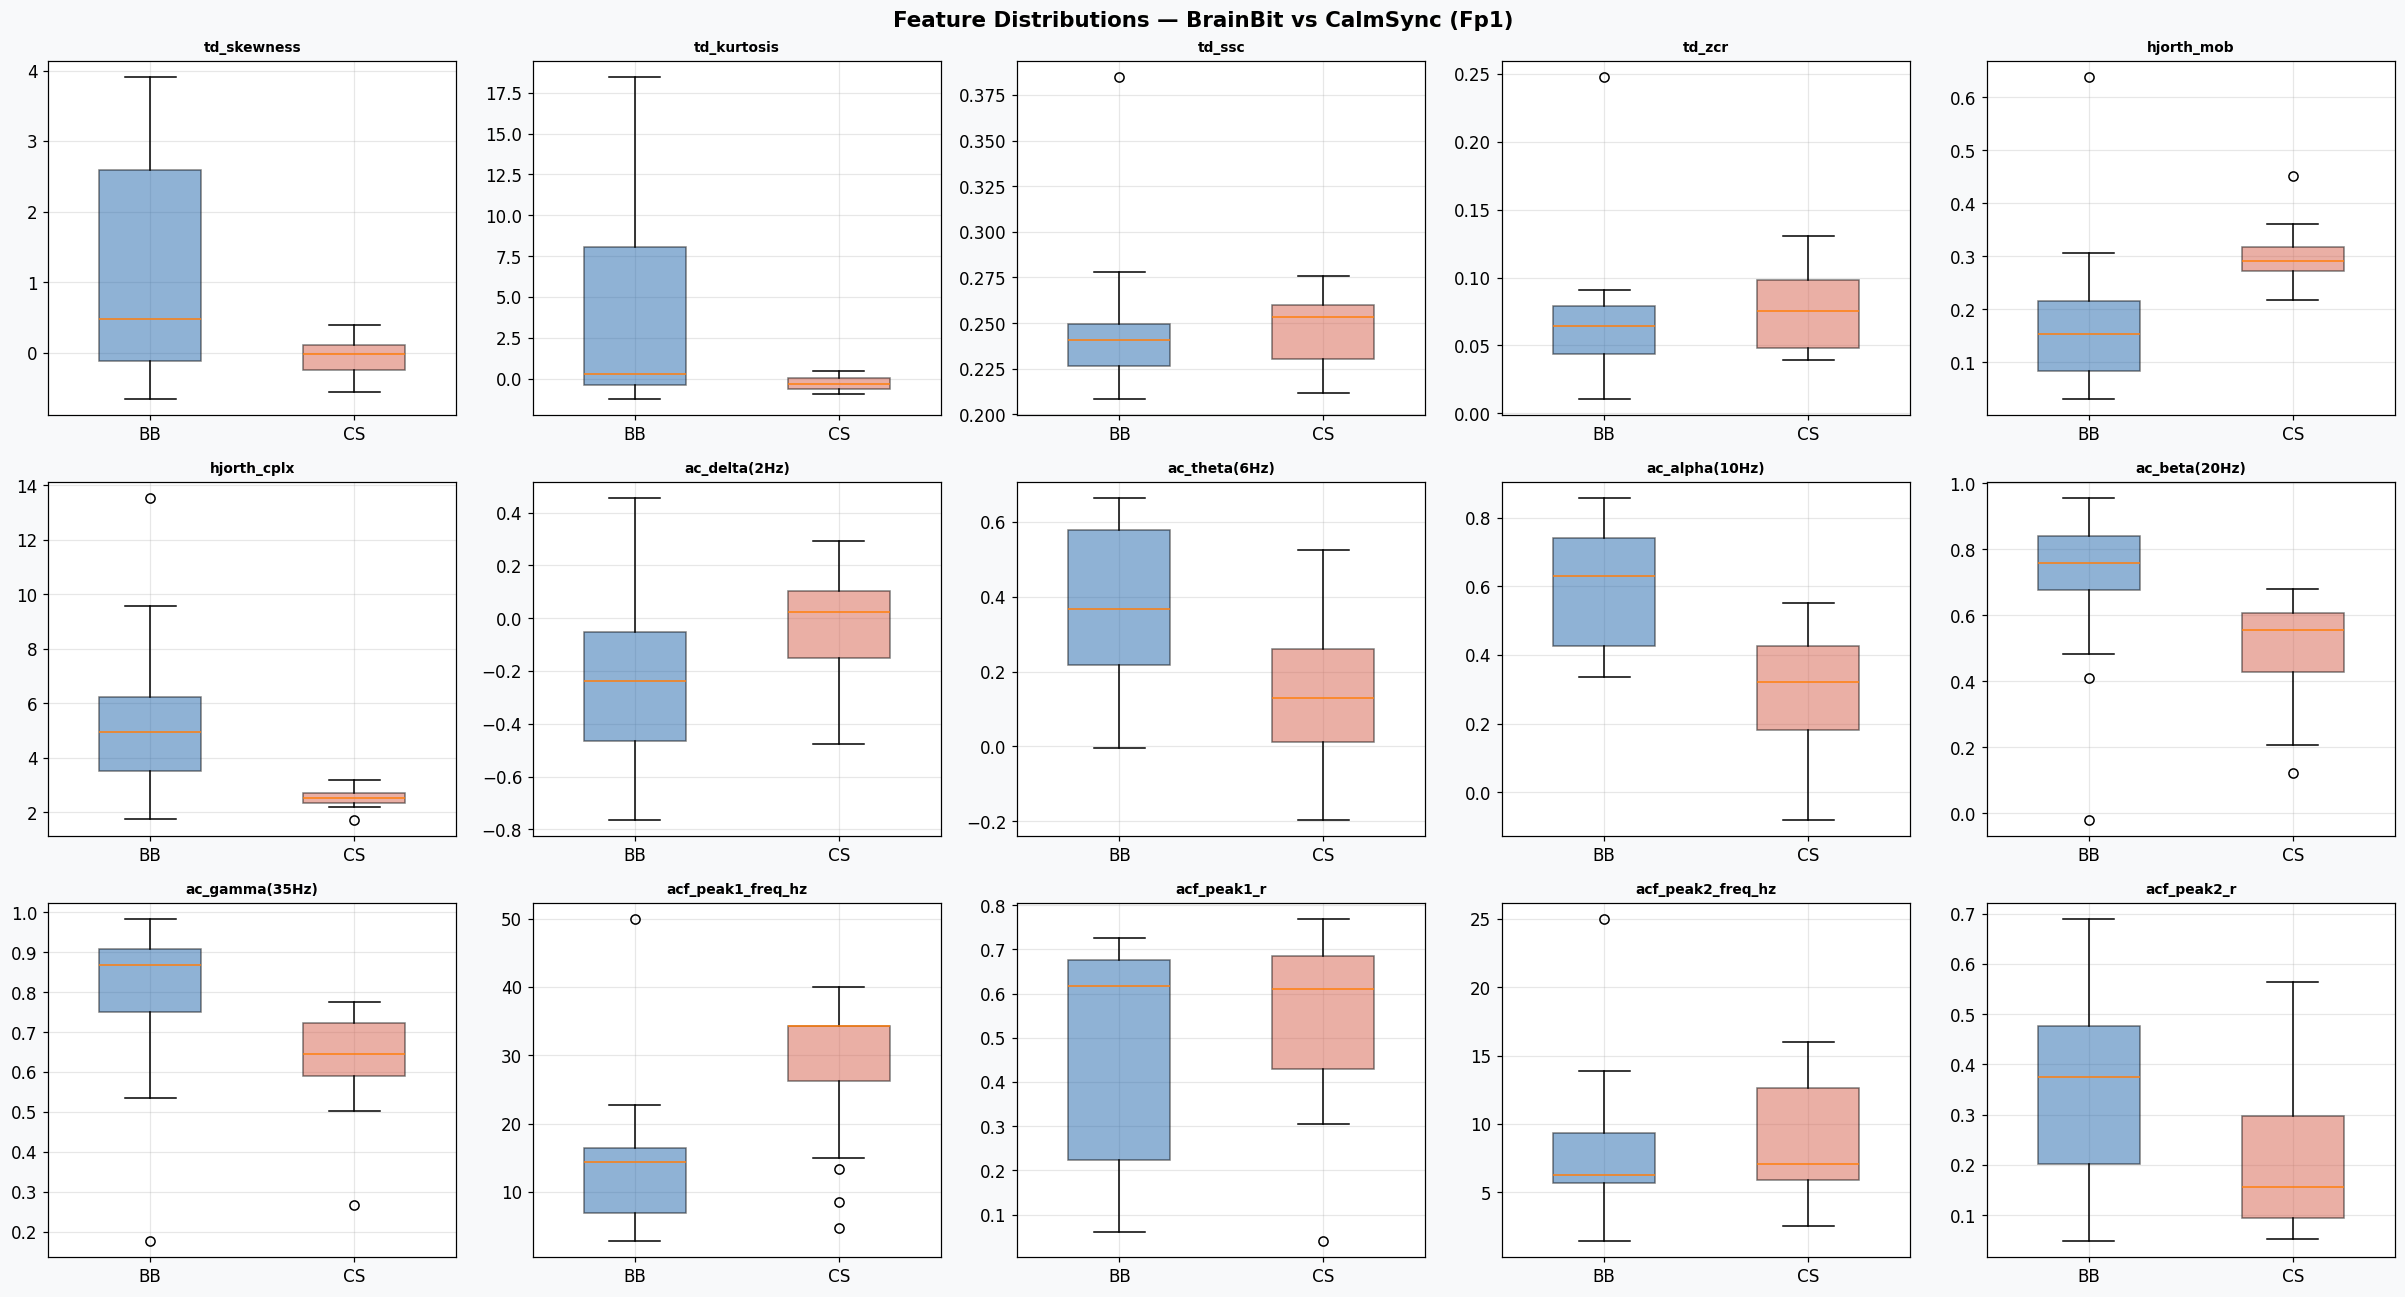

In [18]:
# ── Box plots: BrainBit vs CalmSync (Fp1 only) ───────────────────────────────
feat_cols = [c for c in df_all.columns if c.startswith(('td_', 'hjorth', 'ac_', 'acf_'))]
df_fp1 = df_all[df_all['channel'] == 'Fp1'].copy()

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes_flat = axes.flat

for ax, feat in zip(axes_flat, feat_cols):
    data_bb = df_fp1[df_fp1['device'] == 'BrainBit'][feat].dropna()
    data_cs = df_fp1[df_fp1['device'] == 'CalmSync'][feat].dropna()
    bp = ax.boxplot([data_bb, data_cs], labels=['BB', 'CS'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(C_FP1)
    bp['boxes'][1].set_facecolor(C_FP2)
    for b in bp['boxes']:
        b.set_alpha(0.5)
    ax.set_title(feat, fontsize=9)

# Hide unused axes
for ax in axes_flat[len(feat_cols):]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions — BrainBit vs CalmSync (Fp1)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5b · Within-device: Liked vs Disliked

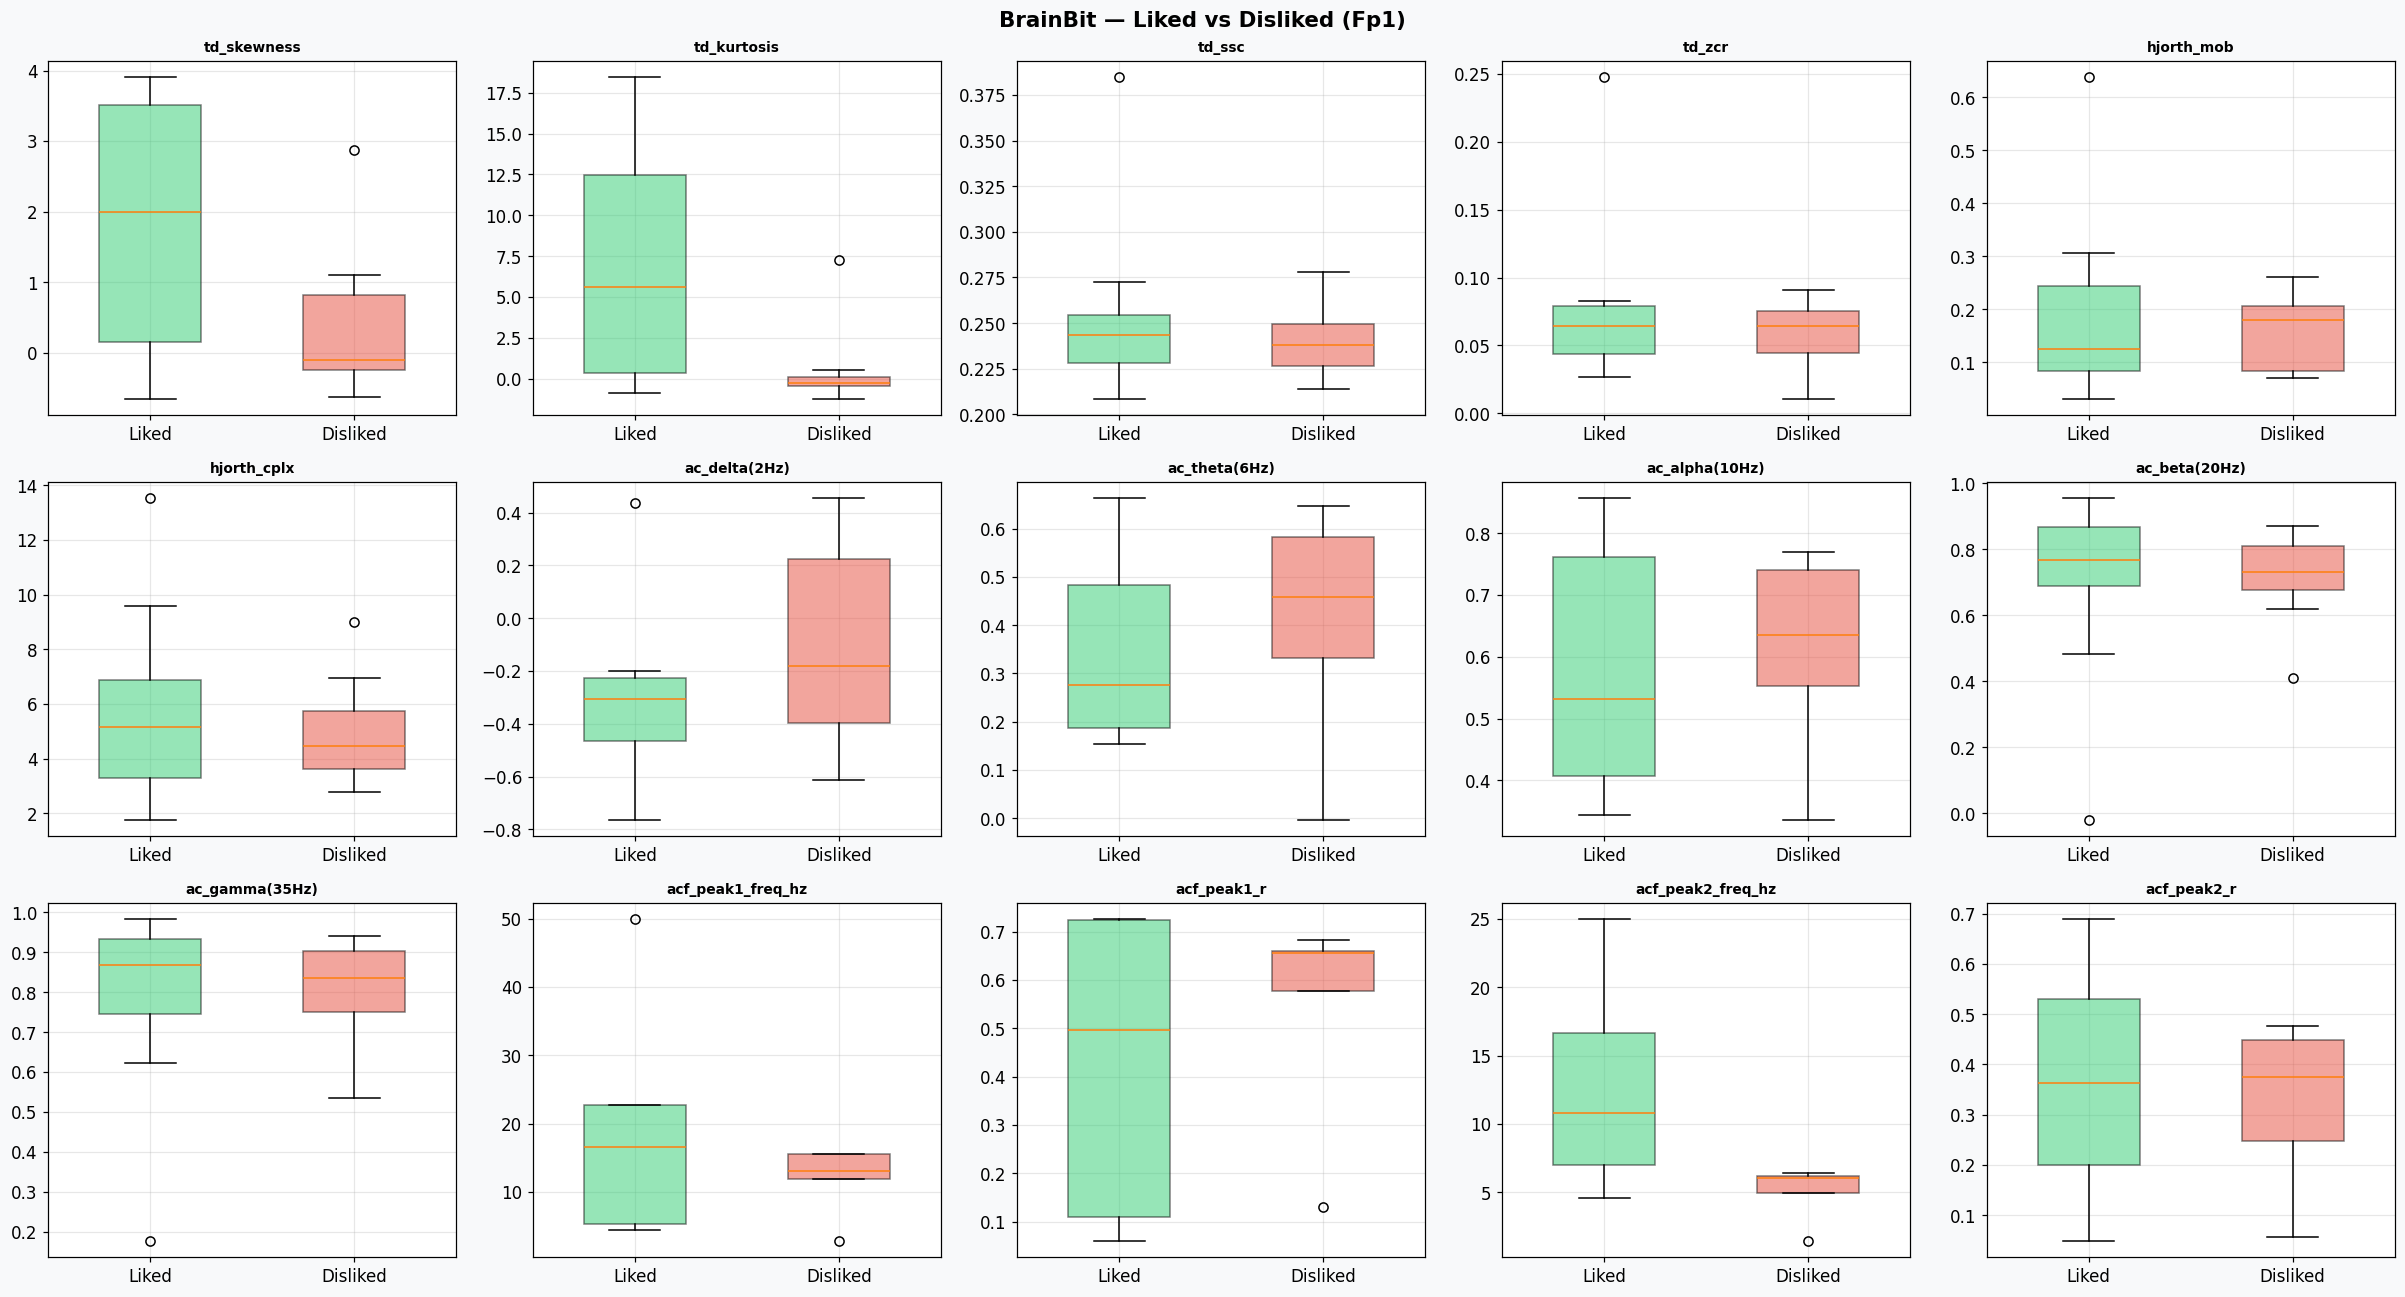

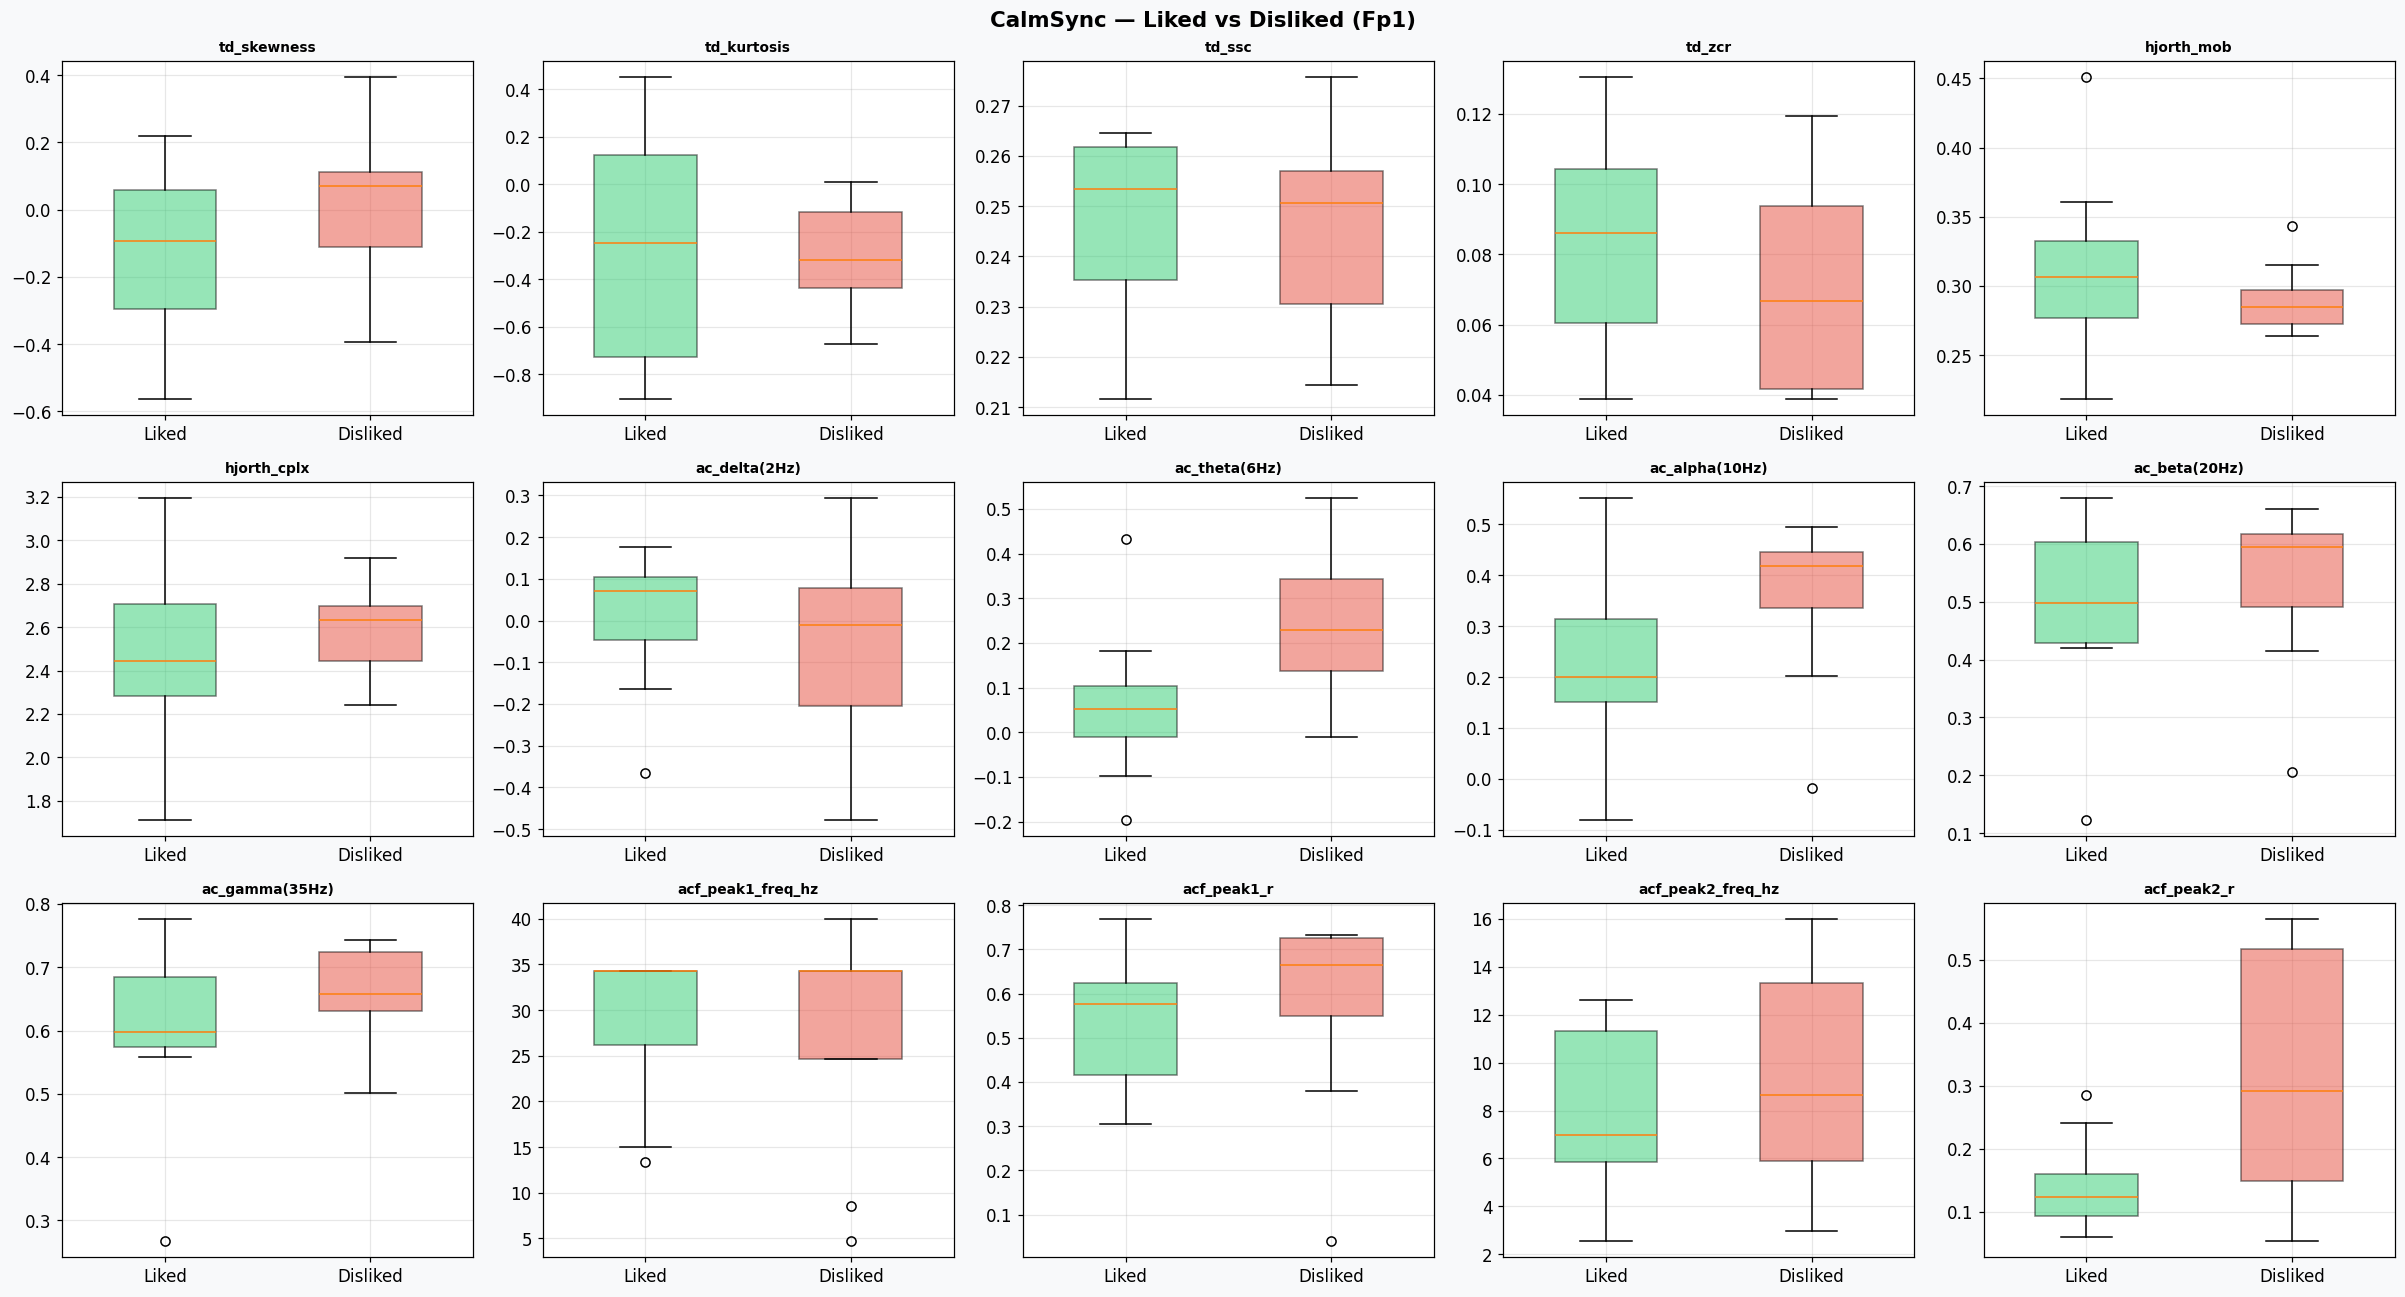

In [19]:
# ── Liked vs Disliked per device ─────────────────────────────────────────────
for device in ['BrainBit', 'CalmSync']:
    df_dev = df_fp1[df_fp1['device'] == device]
    df_liked    = df_dev[df_dev['condition'] == 'liked']
    df_disliked = df_dev[df_dev['condition'] == 'disliked']

    if len(df_liked) == 0 or len(df_disliked) == 0:
        print(f'{device}: not enough liked/disliked trials to compare')
        continue

    fig, axes = plt.subplots(3, 5, figsize=(22, 12))
    for ax, feat in zip(axes.flat, feat_cols):
        d_l = df_liked[feat].dropna()
        d_d = df_disliked[feat].dropna()
        bp = ax.boxplot([d_l, d_d], labels=['Liked', 'Disliked'],
                        patch_artist=True, widths=0.5)
        bp['boxes'][0].set_facecolor('#2ecc71')
        bp['boxes'][1].set_facecolor('#e74c3c')
        for b in bp['boxes']:
            b.set_alpha(0.5)
        ax.set_title(feat, fontsize=9)

    for ax in axes.flat[len(feat_cols):]:
        ax.set_visible(False)

    plt.suptitle(f'{device} — Liked vs Disliked (Fp1)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 5c · Single epoch deep-dive

Pick any epoch and see its signal alongside all 15 features.

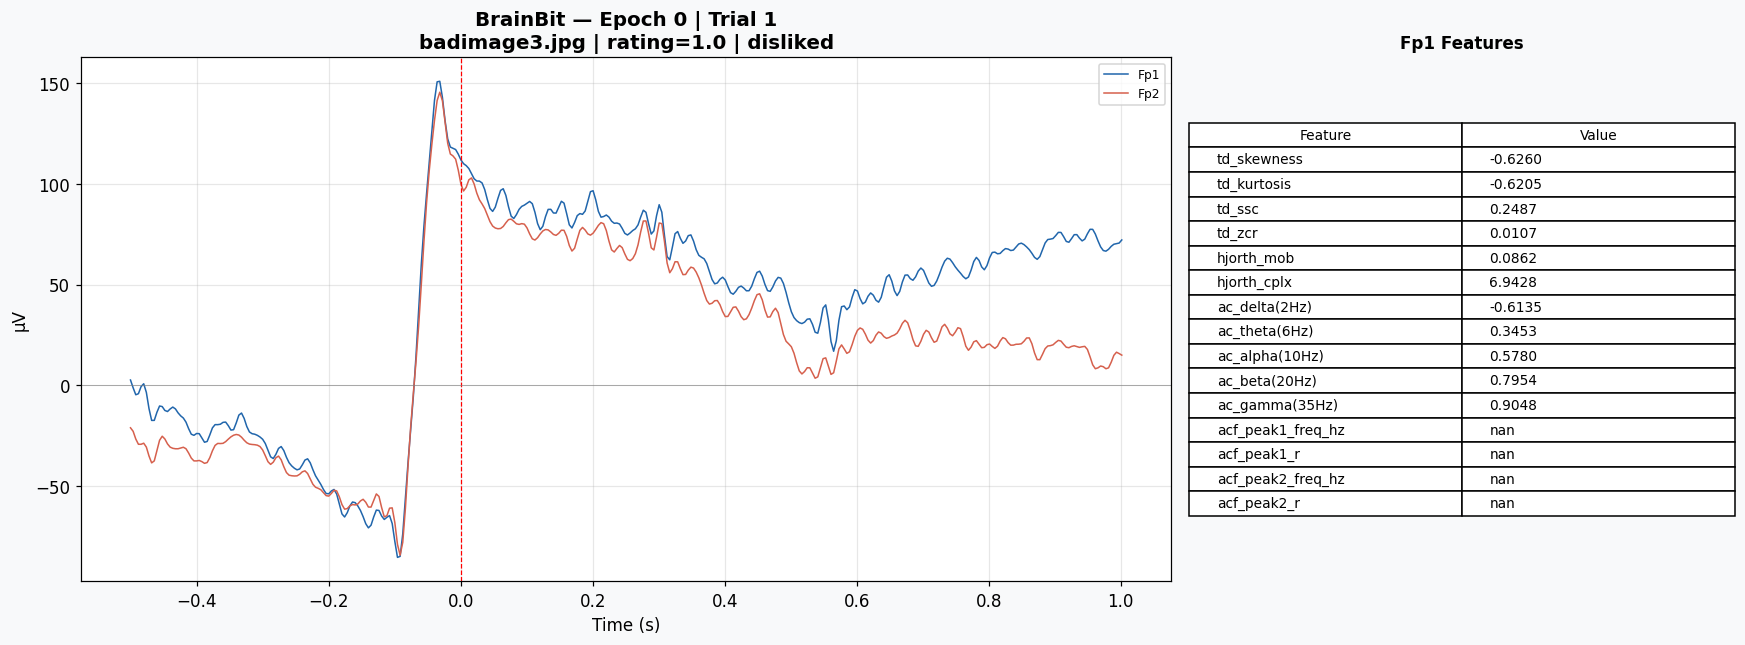

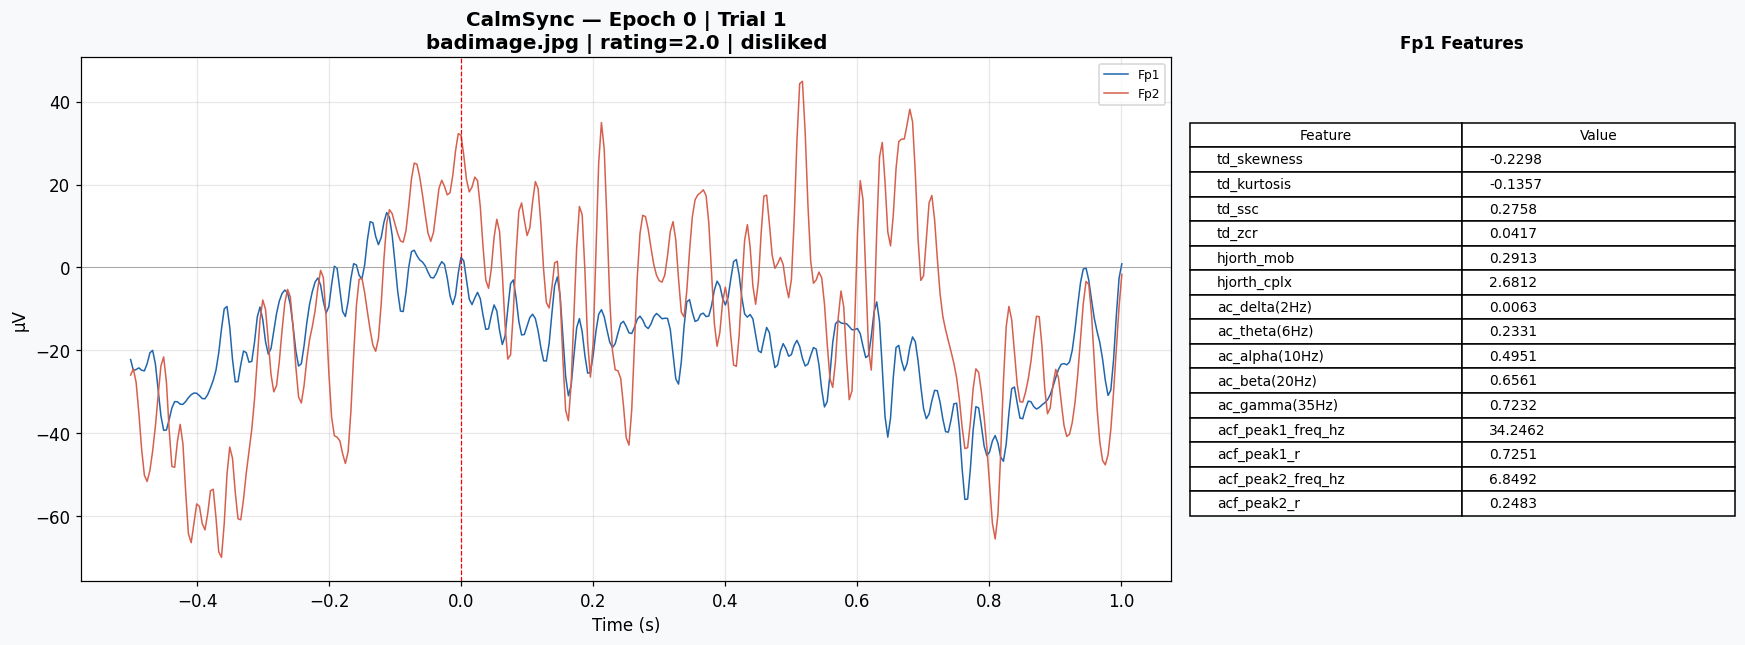

In [20]:
# ── Single epoch viewer ──────────────────────────────────────────────────────
def show_epoch(epochs, epoch_idx, device_name, df_feats):
    """Display one epoch's signal and its features side by side."""
    data_uv = epochs.get_data() * 1e6
    times = epochs.times
    meta = epochs.metadata.iloc[epoch_idx]

    fig = plt.figure(figsize=(16, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

    # Left: signal
    ax_sig = fig.add_subplot(gs[0])
    ax_sig.plot(times, data_uv[epoch_idx, 0], color=C_FP1, lw=1, label='Fp1')
    ax_sig.plot(times, data_uv[epoch_idx, 1], color=C_FP2, lw=1, label='Fp2')
    ax_sig.axvline(0, color='red', ls='--', lw=0.8)
    ax_sig.axhline(0, color='grey', lw=0.4)
    ax_sig.set(xlabel='Time (s)', ylabel='µV',
               title=f"{device_name} — Epoch {epoch_idx} | Trial {int(meta['trial'])}\n"
                     f"{meta['image']} | rating={meta.get('rating','?')} | {meta['condition']}")
    ax_sig.legend(fontsize=8)

    # Right: feature table
    ax_tab = fig.add_subplot(gs[1])
    ax_tab.axis('off')
    row_data = df_feats[(df_feats['device'] == device_name) &
                        (df_feats['epoch_idx'] == epoch_idx) &
                        (df_feats['channel'] == 'Fp1')]
    if len(row_data) == 0:
        ax_tab.text(0.5, 0.5, 'No features found', ha='center')
    else:
        row = row_data.iloc[0]
        feat_names = [c for c in row.index if c.startswith(('td_', 'hjorth', 'ac_', 'acf_'))]
        table_data = [[fn, f'{row[fn]:.4f}'] for fn in feat_names]
        table = ax_tab.table(cellText=table_data, colLabels=['Feature', 'Value'],
                             loc='center', cellLoc='left')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.3)
        ax_tab.set_title('Fp1 Features', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()


# Show epoch 0 from each device
show_epoch(epochs_bb, 0, 'BrainBit', df_all)
show_epoch(epochs_cs, 0, 'CalmSync', df_all)

### 5d · Feature heatmap — all epochs

In [ ]:
# ── Heatmap: epochs × features ───────────────────────────────────────────────
from matplotlib.colors import Normalize

for device in ['BrainBit', 'CalmSync']:
    df_dev = df_fp1[df_fp1['device'] == device].sort_values('epoch_idx')
    mat = df_dev[feat_cols].values
    # Z-score each feature for better visualisation
    mat_z = (mat - np.nanmean(mat, axis=0)) / (np.nanstd(mat, axis=0) + 1e-12)

    fig, ax = plt.subplots(figsize=(16, max(4, len(df_dev) * 0.35)))
    im = ax.imshow(mat_z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_xticks(range(len(feat_cols)))
    ax.set_xticklabels(feat_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(df_dev)))
    trial_labels = [f"T{int(r['trial'])} {r['condition'][:3]}" for _, r in df_dev.iterrows()]
    ax.set_yticklabels(trial_labels, fontsize=8)
    ax.set(ylabel='Epoch', title=f'{device} — Feature Heatmap (Fp1, z-scored)')
    fig.colorbar(im, ax=ax, label='z-score', shrink=0.8)
    plt.tight_layout()
    plt.show()

---
## 6 · Effect of Artifact Rejection on Features

We re-extract epochs with artifact rejection ON and compare feature distributions.

In [21]:
# ── With artifact rejection ──────────────────────────────────────────────────
print('=== BrainBit with artifact rejection ===')
epochs_bb_rej = make_epochs(raw_bb_filt, BB_CSV, reject_artifact=True)
print()
print('=== CalmSync with artifact rejection ===')
epochs_cs_rej = make_epochs(raw_cs_filt, CS_CSV, reject_artifact=True)

df_bb_rej = extract_all_features(epochs_bb_rej, 'BrainBit')
df_cs_rej = extract_all_features(epochs_cs_rej, 'CalmSync')
df_all_rej = pd.concat([df_bb_rej, df_cs_rej], ignore_index=True)
df_fp1_rej = df_all_rej[df_all_rej['channel'] == 'Fp1']

=== BrainBit with artifact rejection ===
  Artifact rejection: dropped 7/16 epochs
  Epochs: 9  |  conditions: {'disliked': 8, 'liked': 8}

=== CalmSync with artifact rejection ===
  Artifact rejection: dropped 0/16 epochs
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}


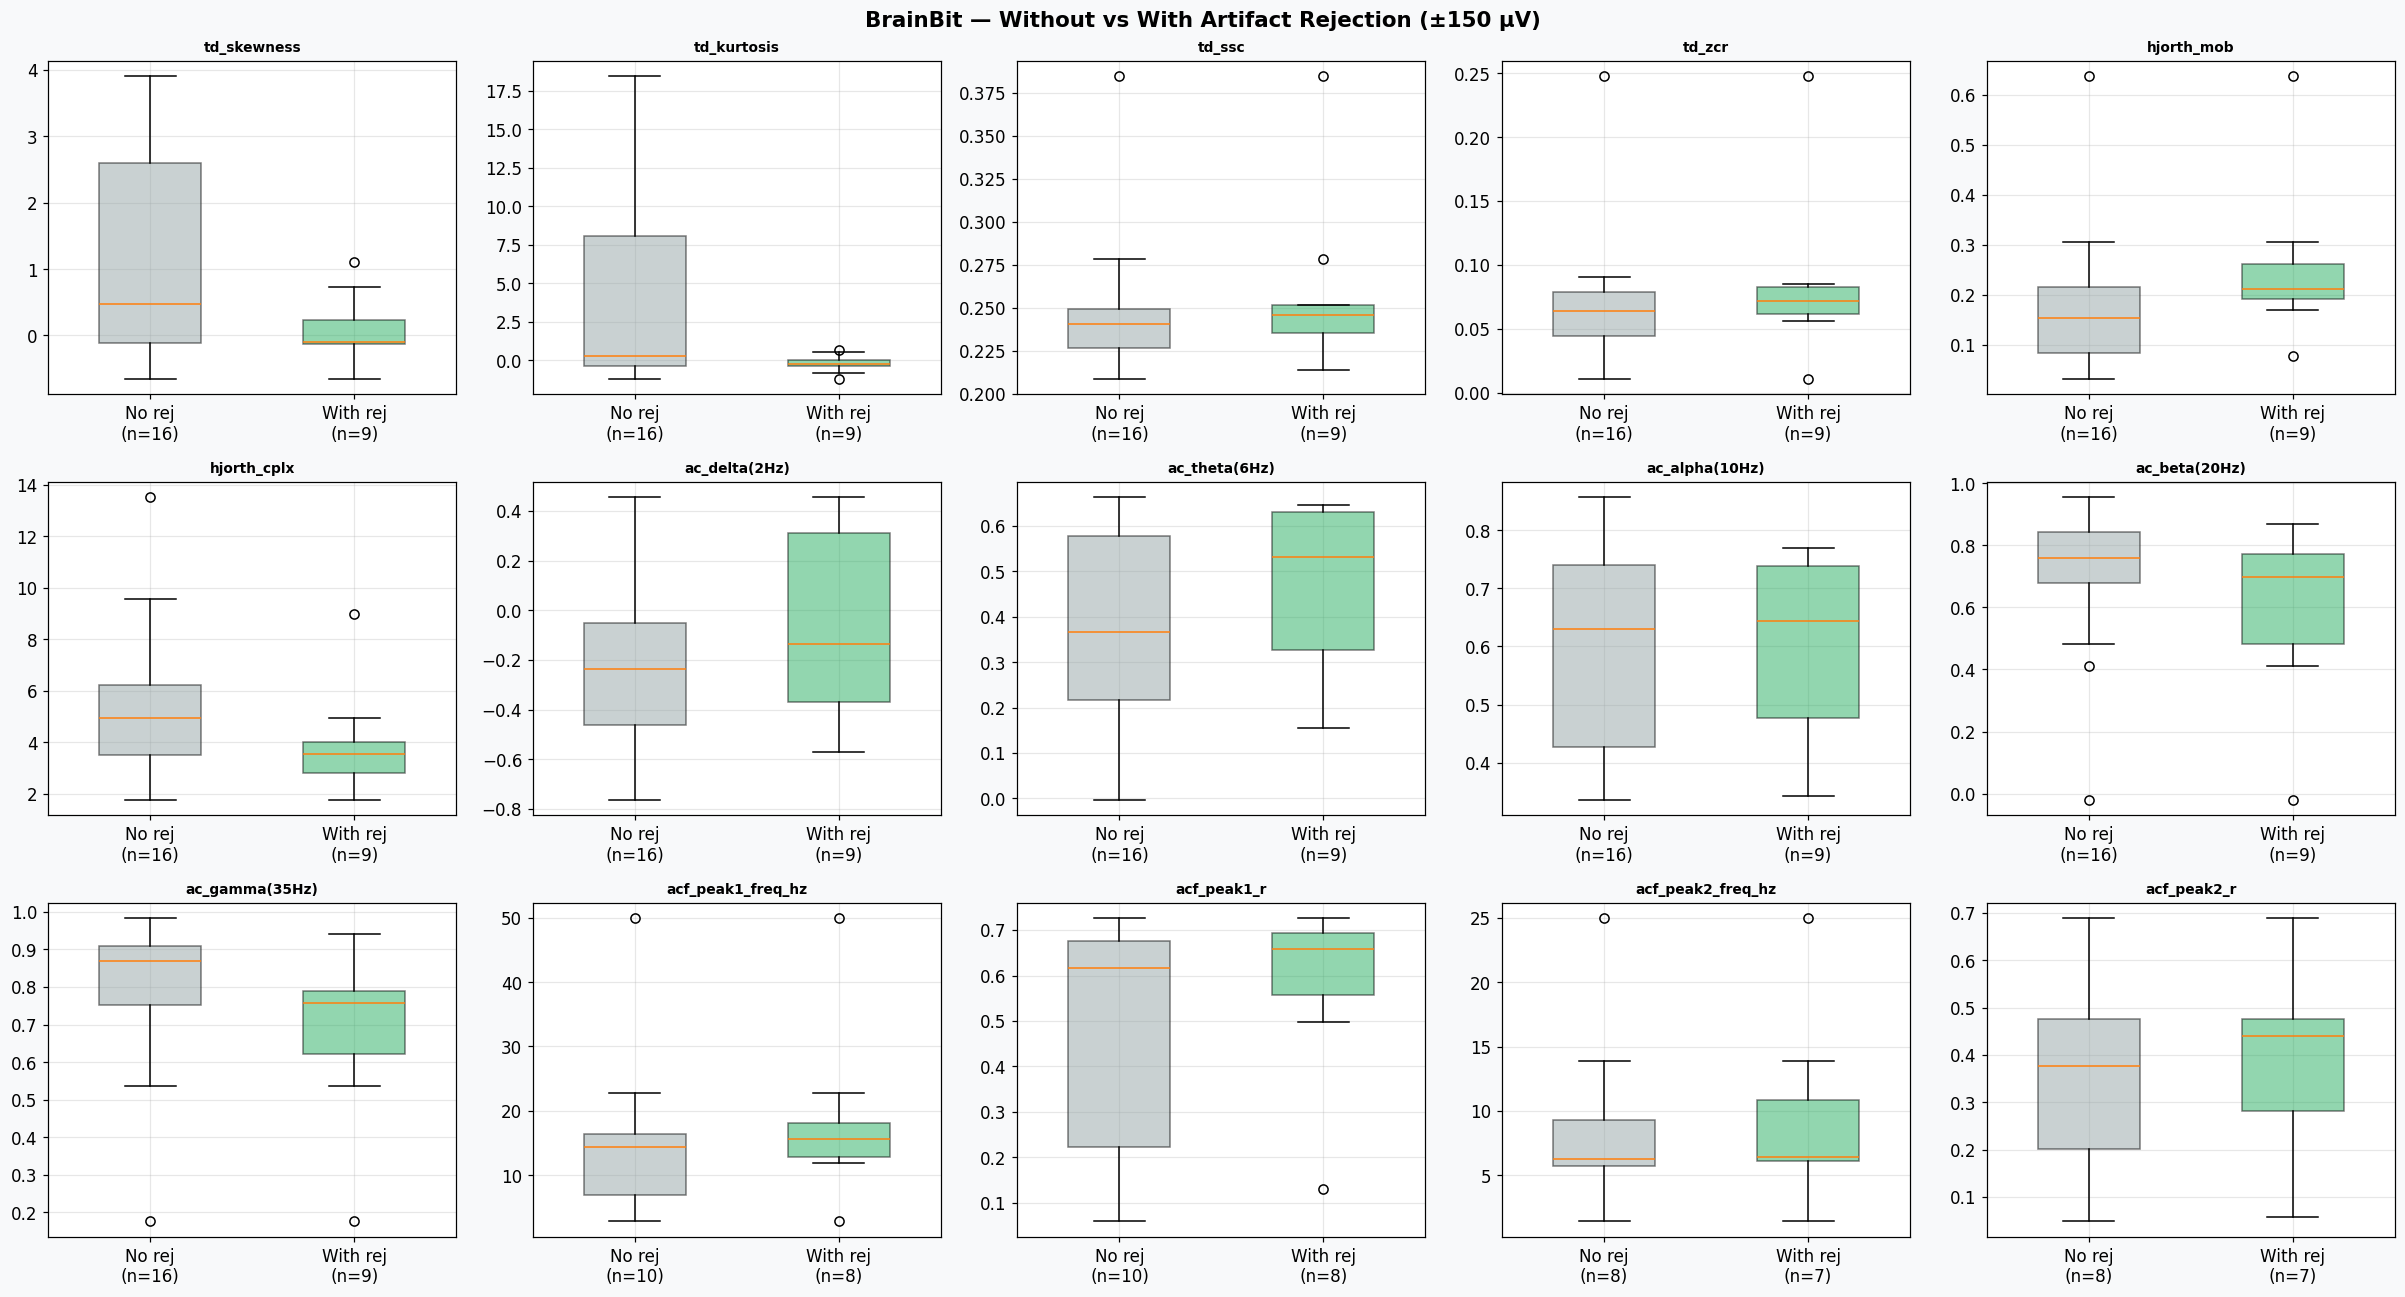

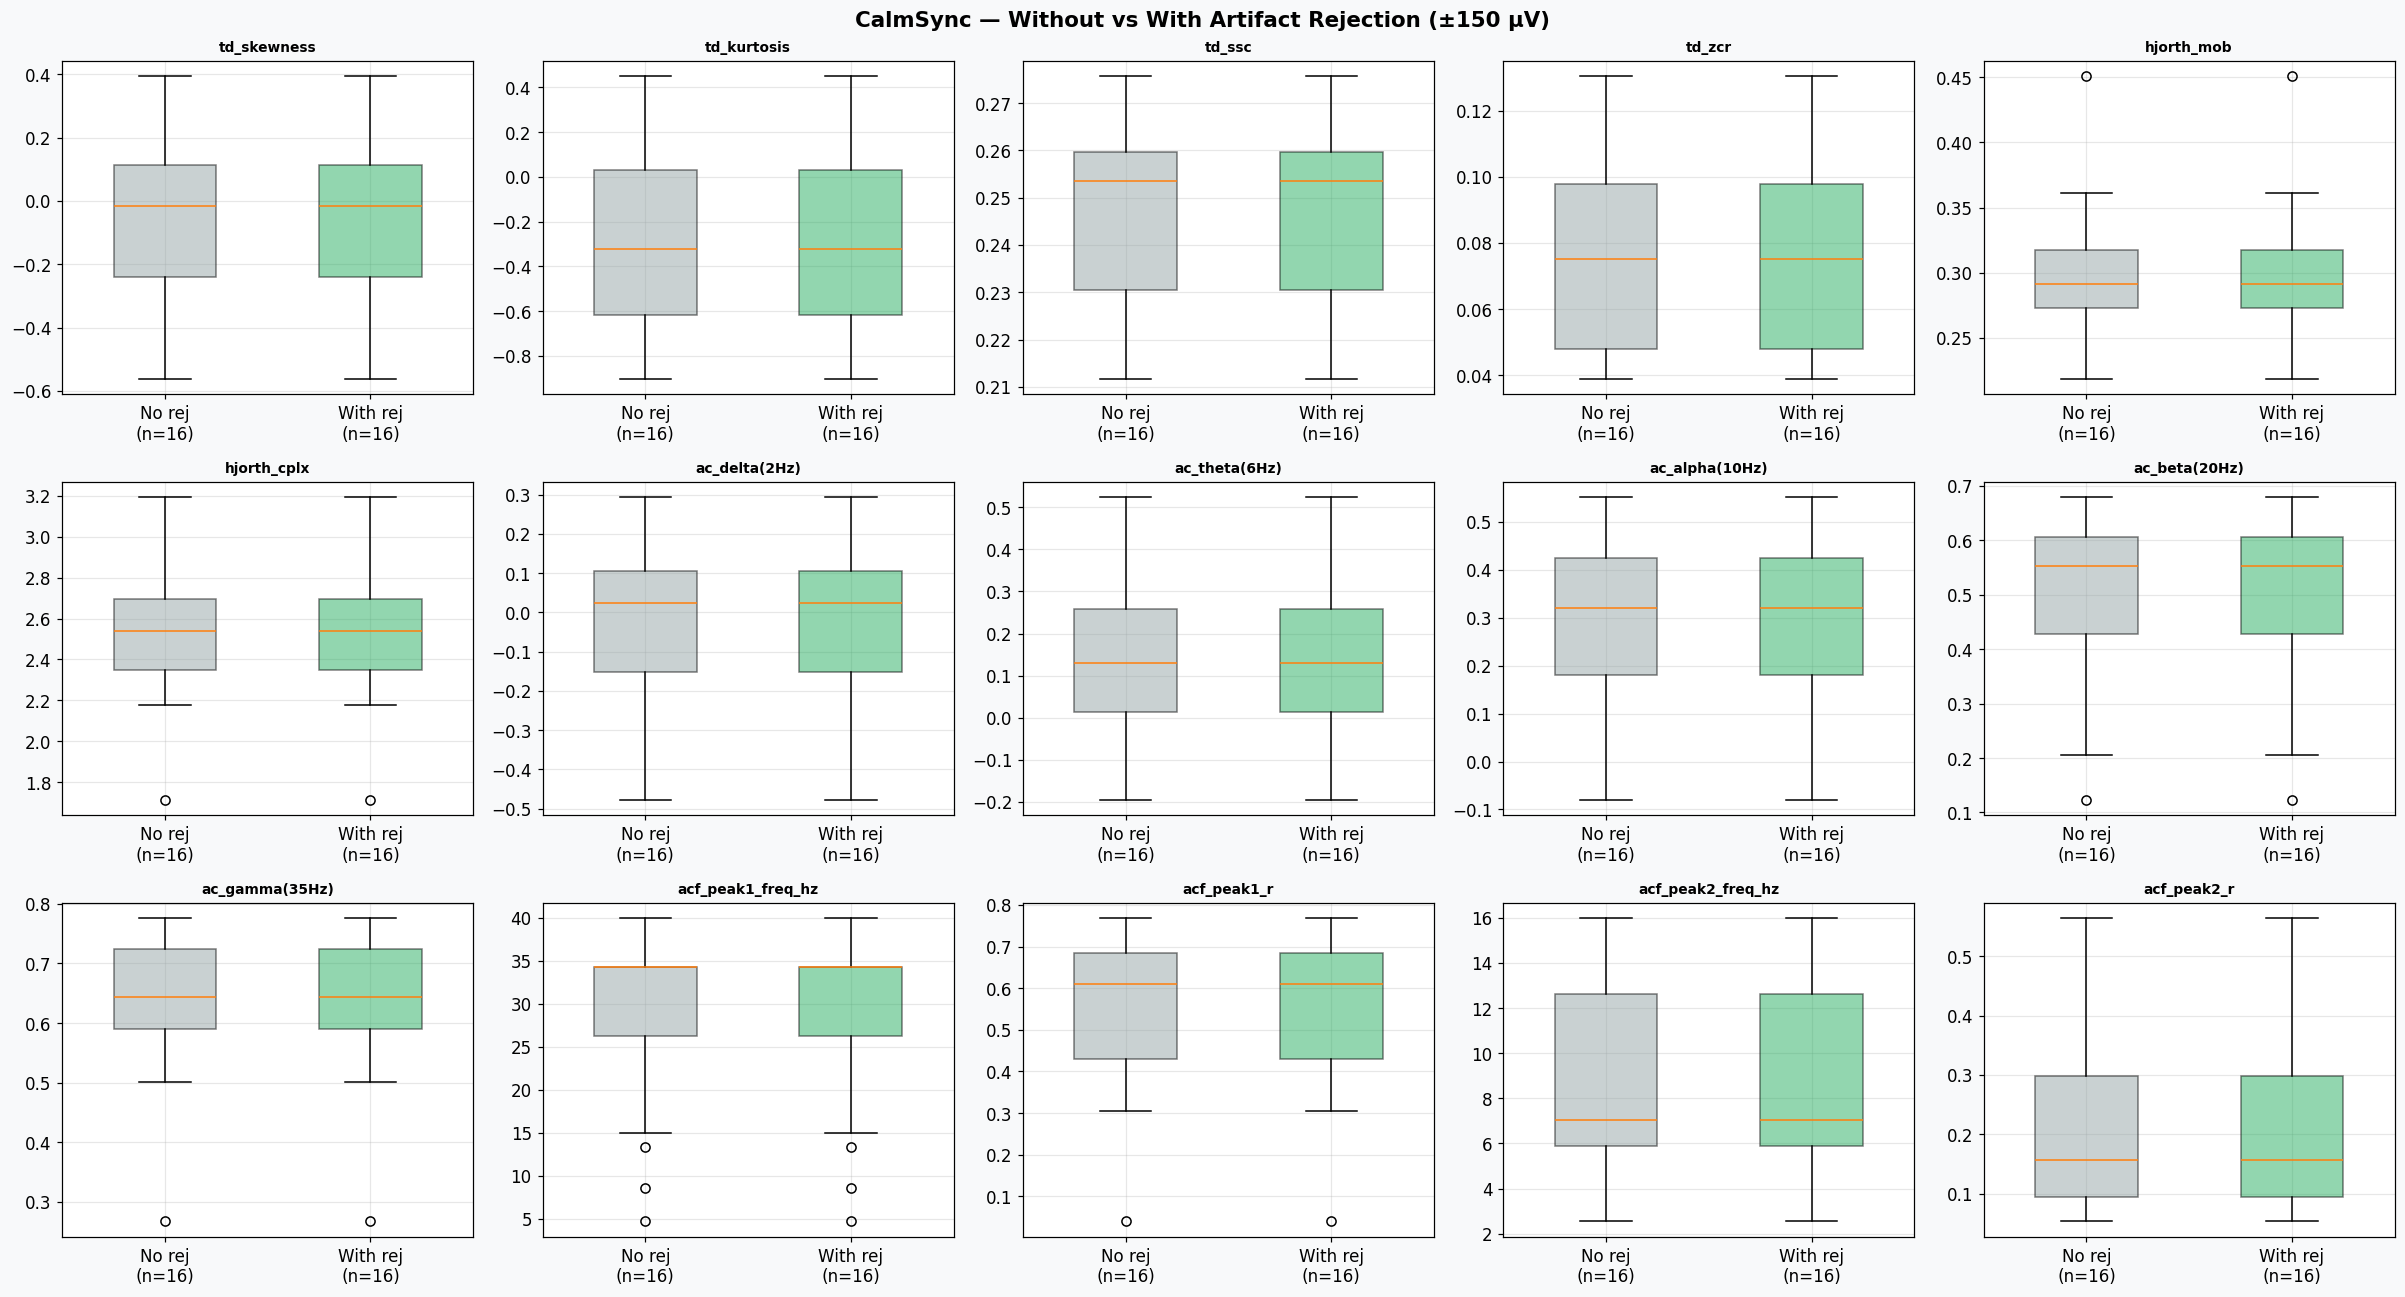

In [22]:
# ── Compare: before vs after artifact rejection ──────────────────────────────
for device in ['BrainBit', 'CalmSync']:
    df_before = df_fp1[df_fp1['device'] == device]
    df_after  = df_fp1_rej[df_fp1_rej['device'] == device]

    fig, axes = plt.subplots(3, 5, figsize=(22, 12))
    for ax, feat in zip(axes.flat, feat_cols):
        d_b = df_before[feat].dropna()
        d_a = df_after[feat].dropna()
        bp = ax.boxplot([d_b, d_a], labels=[f'No rej\n(n={len(d_b)})', f'With rej\n(n={len(d_a)})'],
                        patch_artist=True, widths=0.5)
        bp['boxes'][0].set_facecolor('#95a5a6')
        bp['boxes'][1].set_facecolor('#27ae60')
        for b in bp['boxes']:
            b.set_alpha(0.5)
        ax.set_title(feat, fontsize=9)

    for ax in axes.flat[len(feat_cols):]:
        ax.set_visible(False)

    plt.suptitle(f'{device} — Without vs With Artifact Rejection (±{REJECT_UV:.0f} µV)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6b · Effect of epoch duration on real data

We re-epoch the BrainBit data with different `TMAX` values and see how the features change.

  Artifact rejection: OFF
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}
  Artifact rejection: OFF
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}
  Artifact rejection: OFF
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}
  Artifact rejection: OFF
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}
  Artifact rejection: OFF
  Epochs: 16  |  conditions: {'disliked': 8, 'liked': 8}


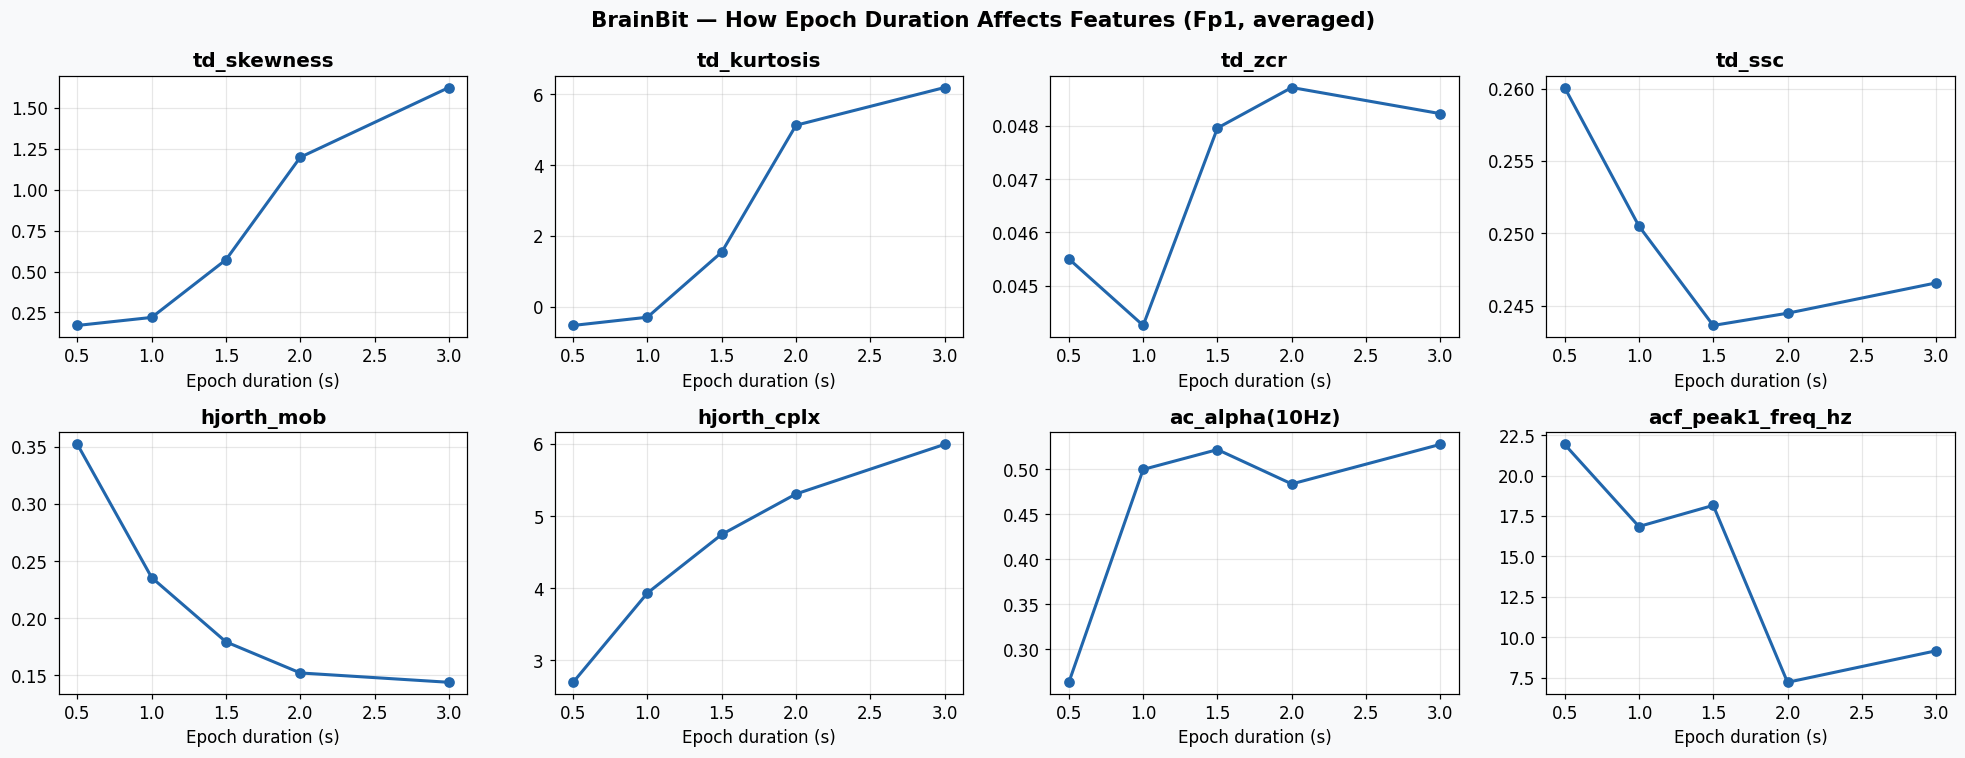

In [23]:
# ── Epoch duration sweep on real data ─────────────────────────────────────────
tmax_values = [0.5, 1.0, 1.5, 2.0, 3.0]
dur_real_rows = []

for tmax_val in tmax_values:
    try:
        ep = make_epochs(raw_bb_filt, BB_CSV, tmin=0.0, tmax=tmax_val,
                         baseline=None, reject_artifact=False)
        data_uv = ep.get_data() * 1e6
        fs_ep = ep.info['sfreq']
        # Average features across all epochs, Fp1 only
        epoch_feats = []
        for i in range(len(ep)):
            epoch_feats.append(extract_features(data_uv[i, 0], fs_ep))
        df_ep = pd.DataFrame(epoch_feats)
        mean_feats = df_ep.mean().to_dict()
        mean_feats['tmax'] = tmax_val
        dur_real_rows.append(mean_feats)
    except Exception as e:
        print(f'  tmax={tmax_val}: {e}')

df_dur_real = pd.DataFrame(dur_real_rows)

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
feat_show = ['td_skewness', 'td_kurtosis', 'td_zcr', 'td_ssc',
             'hjorth_mob', 'hjorth_cplx', 'ac_alpha(10Hz)', 'acf_peak1_freq_hz']

for ax, feat in zip(axes.flat, feat_show):
    if feat in df_dur_real.columns:
        ax.plot(df_dur_real['tmax'], df_dur_real[feat], 'o-', color=C_FP1, lw=2)
        ax.set(xlabel='Epoch duration (s)', title=feat)

plt.suptitle('BrainBit — How Epoch Duration Affects Features (Fp1, averaged)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 · Summary Table

In [ ]:
# ── Summary statistics ───────────────────────────────────────────────────────
summary = df_fp1.groupby('device')[feat_cols].agg(['mean', 'std']).round(4)
print('Feature Summary (Fp1, mean ± std):')
print()

for device in ['BrainBit', 'CalmSync']:
    print(f'\n{device}:')
    for feat in feat_cols:
        m = summary.loc[device, (feat, 'mean')]
        s = summary.loc[device, (feat, 'std')]
        print(f'  {feat:25s}: {m:10.4f} ± {s:.4f}')

---
## Key Takeaways

1. **Skewness & Kurtosis** — detect amplitude asymmetry and sharp transients; kurtosis spikes indicate artifacts
2. **ZCR & SSC** — proxy for dominant frequency and high-frequency content; stable across epoch durations
3. **Hjorth Mobility** — directly proportional to mean frequency; higher for beta/gamma-dominant signals
4. **Hjorth Complexity** — 1.0 for a pure sine; higher values mean more complex waveform
5. **Autocorrelation at band lags** — directly tests for rhythmic activity at specific frequencies
6. **ACF peaks** — model-free way to discover the dominant and secondary rhythms
7. **Epoch duration** — Hjorth and ZCR are robust; ACF-based features need ≥0.5 s
8. **Artifact rejection** — mainly affects kurtosis and skewness (removes extreme-amplitude epochs)

---
*Notebook created for the OSIS Lab — Time-Domain Features Walkthrough*